# F3-B - Estratégia B: tradução direta com primeira autocorreção Nile

Este notebook executa a Estratégia B da Fase 3. A F3-B recebe as 500 saídas produzidas pela F3-A e aplica uma primeira autocorreção somente às saídas que não foram aceitas sintaticamente pelo parser Nile. As saídas já aceitas pelo parser são preservadas sem uma nova chamada ao modelo aluno.

A estratégia mantém exatamente a mesma grade experimental da F3-A:

```text
k=0: zero-shot
k=1, k=3 e k=5:
  seleção aleatória
  seleção lexical
  seleção semântica
```

Assim, a F3-B também produz 500 registros finais, distribuídos em dez condições de 50 exemplos. A quantidade de chamadas de autocorreção é determinada pelos resultados da F3-A: uma chamada é criada para cada saída com `PSR=0`.

A cadeia principal é:

```text
resultado da F3-A
        ↓
saída sintaticamente válida? ── sim ──→ preservar sem nova inferência
        │
        não
        ↓
saída rejeitada + feedback do parser
        ↓
prompt de autocorreção com as mesmas demonstrações da F3-A
        ↓
Qwen2.5-1.5B-Instruct
        ↓
saída Nile corrigida
        ↓
parser, AST, verificação estrutural e métricas
        ↓
comparação F3-A × F3-B
        ↓
f3b_autocorrecao_traducao_direta.zip
```

A referência Nile do exemplo de teste não é fornecida ao modelo durante a autocorreção. Também não são fornecidas a IR, R1, R2 ou R3 do teste. O modelo recebe apenas a entrada em linguagem natural, a própria saída rejeitada, o feedback do validador e, nas condições few-shot, as mesmas demonstrações de treino utilizadas pela F3-A.

A autocorreção é exclusivamente formal e ocorre somente na saída Nile. Ela não gera Representação Intermediária, justificativa ou uma nova tradução direta independente.

| Bloco | Etapa | Função metodológica | Resultado principal |
|---:|---|---|---|
| 1 | Configuração | Fixar estratégia, caminhos, geração e padrão visual | Ambiente da F3-B |
| 2 | Auditoria das entradas | Localizar e verificar F3-modelo e F3-A | Entradas compatíveis |
| 3 | Carga integrada | Ativar módulos formais, base e resultados da F3-A | Base operacional da autocorreção |
| 4 | Plano | Identificar elegíveis e congelar as 500 decisões | `f3b_plano_autocorrecao.csv` |
| 5 | Modelo aluno | Carregar o Qwen2.5-1.5B-Instruct | Modelo pronto |
| 6 | Prompts | Montar, tokenizar e auditar somente os elegíveis | Prompts sem vazamento |
| 7 | Execução | Gerar autocorreções com checkpoint e progresso | Respostas de autocorreção |
| 8 | Avaliação | Consolidar 500 resultados e recalcular métricas | Resultados detalhados |
| 9 | Análise | Produzir tabelas, ganhos e seis gráficos | Comparação F3-A × F3-B |
| 10 | Empacotamento | Executar barreiras finais, manifesto e ZIP | Pacote operacional da F3-B |

## Bloco 1 - Configuração inicial

### Objetivo

Este bloco prepara o ambiente da F3-B e concentra todas as escolhas que devem permanecer fixas durante a execução. A configuração é compatível com a F3-A para garantir que a única diferença experimental seja a primeira autocorreção das saídas rejeitadas sintaticamente.

### Configurações principais

O bloco define:

- estratégia `F3-B` e variante `primeira_ac`;
- conjunto CAMPI com 50 exemplos e cinco folds;
- dez condições e 500 registros finais;
- `k=0`, `k=1`, `k=3` e `k=5`;
- regime zero-shot e métodos Aleatória, Lexical e Semântica;
- ordem oficial de exibição: Aleatória, Lexical e Semântica;
- modelo aluno `Qwen2.5-1.5B-Instruct`;
- geração determinística, sem amostragem;
- máximo de 256 novos tokens para a correção Nile;
- autocorreção somente quando a saída inicial possui `PSR=0`;
- checkpoint, retomada e modo de teste rápido.

### Artefatos finais

Os caminhos de prompts, auditoria de tokens, gerações, resultados, comparações, gráficos, manifesto e ZIP são definidos antecipadamente. Nenhum nome é criado de forma improvisada durante a execução.

### Reprodutibilidade

Cada chamada recebe uma semente derivada da semente global, do fold, do ID, do método e de `k`. Os prompts, resultados de origem e configurações são associados por hashes SHA-256.

### Resultado esperado

O ambiente estará pronto, sem carregar dados ou modelo. O Bloco 1 não apresenta tabelas.

In [1]:
# ----------------------------------------------------------
# 1.1 Importação das bibliotecas principais
# ----------------------------------------------------------

import gc
import gzip
import hashlib
import importlib.metadata
import json
import os
import platform
import re
import shutil
import sys
import time
import traceback
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


# ----------------------------------------------------------
# 1.2 Identificação da estratégia
# ----------------------------------------------------------

FASE = "F3-B"
ESTRATEGIA = "F3-B"
VARIANTE = "primeira_ac"
NOME_ESTRATEGIA = "Tradução direta com primeira autocorreção Nile"
DATASET = "CAMPI"

TOTAL_EXEMPLOS_ESPERADO = 50
TOTAL_FOLDS_ESPERADO = 5
TOTAL_CONDICOES_ESPERADO = 10
TOTAL_REGISTROS_ESPERADO = 500
SEED_GLOBAL = 42

K_ZERO_SHOT = [0]
K_FEWSHOT = [1, 3, 5]
VALORES_K = [0, 1, 3, 5]

METODO_ZERO_SHOT = "zero_shot"
METODOS_FEWSHOT = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]

ORDEM_METODOS_EXIBICAO = [
    METODO_ZERO_SHOT,
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]
ORDEM_METODOS_MAPA = {
    metodo: posicao
    for posicao, metodo in enumerate(ORDEM_METODOS_EXIBICAO)
}

ROTULOS_METODOS = {
    "zero_shot": "Nenhum (zero-shot)",
    "random_seed42": "Aleatória",
    "lexical_tfidf": "Lexical",
    "semantic_embeddings": "Semântica",
}

CORES_METODOS = {
    "zero_shot": "#d62728",
    "random_seed42": "#f2c94c",
    "lexical_tfidf": "#2ca02c",
    "semantic_embeddings": "#1f77b4",
}

METRICAS = ["psr", "em", "ed", "ned", "sla_s", "sla_f"]
ROTULOS_METRICAS = {
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}

AUTOCORRIGIR_APENAS_SINTATICAMENTE_INVALIDAS = True


# ----------------------------------------------------------
# 1.3 Modelo aluno e geração
# ----------------------------------------------------------

MODELO_ALUNO = "Qwen2.5-1.5B-Instruct"
MODELO_HF_ID = "Qwen/Qwen2.5-1.5B-Instruct"
MODELO_LOCAL_HINTS = ["qwen2.5", "1.5b", "instruct"]

USAR_CUDA = True
PERMITIR_DOWNLOAD_HUGGINGFACE = True
MAX_NEW_TOKENS_NILE = 256
DO_SAMPLE = False
LIMITE_CONTEXTO_FALLBACK = 32768


# ----------------------------------------------------------
# 1.4 Controle de execução
# ----------------------------------------------------------

REINICIAR_EXECUCAO = False
MODO_TESTE_RAPIDO = False
TOTAL_REGISTROS_TESTE_RAPIDO = 5
INTERVALO_SNAPSHOT = 25


# ----------------------------------------------------------
# 1.5 Diretórios principais
# ----------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")
RAIZ_TRABALHO = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("/mnt/data/f3b_working")
)

F3B_DIR = RAIZ_TRABALHO / "f3b_autocorrecao_traducao_direta"
ENTRADAS_DIR = F3B_DIR / "entradas"
INTERMEDIARIOS_DIR = F3B_DIR / "intermediarios"
GRAFICOS_DIR = F3B_DIR / "graficos"
PACOTE_DIR = F3B_DIR / "pacote"
F3_MODELO_DIR = ENTRADAS_DIR / "f3_modelo_operacional"
F3A_OPERACIONAL_DIR = ENTRADAS_DIR / "f3a_traducao_direta"

if REINICIAR_EXECUCAO and F3B_DIR.exists():
    shutil.rmtree(F3B_DIR)

for diretorio in [
    F3B_DIR,
    ENTRADAS_DIR,
    INTERMEDIARIOS_DIR,
    GRAFICOS_DIR,
    PACOTE_DIR,
]:
    diretorio.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------
# 1.6 Caminhos dos artefatos da F3-B
# ----------------------------------------------------------

CONFIG_PATH = PACOTE_DIR / "f3b_config.json"
PLANO_PATH = PACOTE_DIR / "f3b_plano_autocorrecao.csv"
PROMPTS_PATH = PACOTE_DIR / "f3b_prompts.jsonl.gz"
TOKEN_AUDIT_PATH = PACOTE_DIR / "f3b_token_audit.csv"
CHECKPOINT_PATH = INTERMEDIARIOS_DIR / "f3b_checkpoint.jsonl"
GENERATIONS_PATH = PACOTE_DIR / "f3b_generations.jsonl.gz"
RESULTS_JSONL_PATH = PACOTE_DIR / "f3b_results.jsonl"
RESULTS_CSV_PATH = PACOTE_DIR / "f3b_results.csv"
SUMMARY_PATH = PACOTE_DIR / "f3b_summary.csv"
SUMMARY_FOLD_PATH = PACOTE_DIR / "f3b_summary_by_fold.csv"
INVALID_PATH = PACOTE_DIR / "f3b_invalid_outputs.csv"
ANALYSIS_EXAMPLE_PATH = PACOTE_DIR / "f3b_analysis_by_example.csv"
EXECUTION_AUDIT_PATH = PACOTE_DIR / "f3b_execution_audit.csv"
COMPARISON_PATH = PACOTE_DIR / "f3b_comparison_f3a_f3b.csv"
GAINS_PATH = PACOTE_DIR / "f3b_gains.csv"
MANIFEST_PATH = PACOTE_DIR / "manifest.json"
ZIP_FINAL_PATH = RAIZ_TRABALHO / "f3b_autocorrecao_traducao_direta.zip"


# ----------------------------------------------------------
# 1.7 Funções de leitura, escrita e hashing
# ----------------------------------------------------------

def canonical_json(data):
    return json.dumps(
        data,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


def sha256_text(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, ensure_ascii=False, indent=2)
        handle.write("\n")


def read_jsonl(path):
    records = []
    path = Path(path)
    if not path.exists():
        return records
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSONL inválido em {path}, linha {line_number}: {exc}"
                ) from exc
            if not isinstance(record, dict):
                raise TypeError(
                    f"Registro não é objeto em {path}, linha {line_number}."
                )
            records.append(record)
    return records


def locate_jsonl_variant(directory, compressed_name):
    directory = Path(directory)
    compressed = directory / compressed_name
    plain = directory / compressed_name.removesuffix(".gz")
    if compressed.is_file():
        return compressed
    if plain.is_file():
        return plain
    raise FileNotFoundError(
        f"Nenhuma variante localizada: {compressed.name} ou {plain.name}."
    )


def write_jsonl(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")


def append_jsonl(record, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
        handle.write("\n")
        handle.flush()
        os.fsync(handle.fileno())


def write_jsonl_gz(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")


def package_version(name):
    try:
        return importlib.metadata.version(name)
    except Exception:
        return None


def clean_runtime_caches(root):
    root = Path(root)
    for cache in root.rglob("__pycache__"):
        if cache.is_dir():
            shutil.rmtree(cache, ignore_errors=True)
    for suffix in ("*.pyc", "*.pyo"):
        for item in root.rglob(suffix):
            item.unlink(missing_ok=True)


# ----------------------------------------------------------
# 1.8 Padrão visual das tabelas
# ----------------------------------------------------------

CONTADOR_TABELAS = 0

ROTULOS_COLUNAS = {
    "execution_id": "ID da execução",
    "source_execution_id": "ID da execução F3-A",
    "fold": "fold",
    "id": "ID",
    "test_id": "ID de teste",
    "strategy": "estratégia",
    "variant": "variante",
    "selection_method": "método de seleção",
    "selection_label": "rótulo do método",
    "k": "k",
    "records": "registros",
    "eligible_records": "elegíveis à autocorreção",
    "autocorrection_applied": "autocorreção aplicada",
    "syntax_valid_before": "validade sintática antes",
    "syntax_valid_after": "validade sintática depois",
    "syntax_recovered": "sintaxe recuperada",
    "status": "status",
    "item": "item",
    "value": "valor",
    "file": "arquivo",
    "path": "caminho",
    "size_bytes": "tamanho em bytes",
    "sha256": "SHA-256",
    "prompt_tokens": "tokens do prompt",
    "generated_tokens": "tokens gerados",
    "elapsed_seconds": "tempo em segundos",
    "syntax_valid": "validade sintática",
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}


def _display_value(value):
    if isinstance(value, (bool, np.bool_)):
        return "sim" if value else "não"
    if value is None:
        return "-"
    try:
        if not isinstance(value, str) and pd.isna(value):
            return "-"
    except Exception:
        pass
    return value


def exibir_tabela(df, titulo=None, altura_px=None, mostrar_indice=False):
    global CONTADOR_TABELAS
    if df is None:
        print("Tabela não disponível.")
        return
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    if df.empty:
        print("Tabela vazia.")
        return

    CONTADOR_TABELAS += 1
    tabela = df.copy()
    for coluna in tabela.columns:
        tabela[coluna] = tabela[coluna].apply(_display_value)
    tabela = tabela.rename(
        columns={
            coluna: ROTULOS_COLUNAS.get(coluna, str(coluna).replace("_", " "))
            for coluna in tabela.columns
        }
    )

    titulo_final = f"Tabela {CONTADOR_TABELAS}"
    if titulo:
        titulo_final += f". {titulo}"

    html_tabela = tabela.to_html(
        escape=True,
        index=mostrar_indice,
        border=0,
        justify="left",
        classes="tabela_saida",
    )
    altura_css = (
        "overflow-y: visible;"
        if altura_px is None
        else f"max-height: {altura_px}px; overflow-y: auto;"
    )

    display(HTML(f"""
    <div style="font-weight:600;font-size:15px;margin:8px 0 6px;color:#f1f1f1;">
        {titulo_final}
    </div>
    <div class="container_tabela_saida" style="display:inline-block;max-width:100%;overflow-x:auto;{altura_css}border:none;margin:8px 0 12px;">
        <style>
            .container_tabela_saida table.tabela_saida {{
                border-collapse:collapse !important;
                table-layout:auto !important;
                width:auto !important;
                font-family:Arial,sans-serif !important;
                font-size:13px !important;
                background:#111 !important;
                color:#f1f1f1 !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida thead th {{
                position:sticky !important;
                top:0 !important;
                z-index:2 !important;
                background:#2b2b2b !important;
                color:#fff !important;
                padding:7px !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #777 !important;
                border-bottom:2px solid #888 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody td {{
                padding:7px !important;
                vertical-align:top !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(even) td {{background:#1b1b1b !important;}}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(odd) td {{background:#111 !important;}}
        </style>
        {html_tabela}
    </div>
    """))


# ----------------------------------------------------------
# 1.9 Registro da configuração inicial
# ----------------------------------------------------------

configuracao_inicial = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variant": VARIANTE,
    "dataset": DATASET,
    "expected_examples": TOTAL_EXEMPLOS_ESPERADO,
    "expected_folds": TOTAL_FOLDS_ESPERADO,
    "expected_conditions": TOTAL_CONDICOES_ESPERADO,
    "expected_records": TOTAL_REGISTROS_ESPERADO,
    "seed": SEED_GLOBAL,
    "k_values": VALORES_K,
    "selection_methods": [METODO_ZERO_SHOT, *METODOS_FEWSHOT],
    "autocorrection_policy": {
        "only_syntax_invalid": AUTOCORRIGIR_APENAS_SINTATICAMENTE_INVALIDAS,
        "reference_nile_exposed": False,
        "intermediate_representation_used": False,
        "rationales_used": False,
    },
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "resume": {
        "restart": REINICIAR_EXECUCAO,
        "checkpoint": str(CHECKPOINT_PATH),
    },
    "quick_test": {
        "enabled": MODO_TESTE_RAPIDO,
        "records": TOTAL_REGISTROS_TESTE_RAPIDO,
    },
}
write_json(configuracao_inicial, CONFIG_PATH)

print("Bloco 1 concluído.")
print(f"Estratégia: {ESTRATEGIA} - {NOME_ESTRATEGIA}")
print(f"Execução oficial: {'não' if MODO_TESTE_RAPIDO else 'sim'}")
print(f"Retomada de checkpoint: {'não' if REINICIAR_EXECUCAO else 'sim'}")
print(f"Diretório de trabalho: {F3B_DIR}")
print("Status: OK")

Bloco 1 concluído.
Estratégia: F3-B - Tradução direta com primeira autocorreção Nile
Execução oficial: sim
Retomada de checkpoint: sim
Diretório de trabalho: /kaggle/working/f3b_autocorrecao_traducao_direta
Status: OK


## Bloco 2 - Localização e auditoria do F3-modelo e da F3-A

### Objetivo

Este bloco localiza as duas entradas operacionais da F3-B e confirma que ambas pertencem à mesma cadeia experimental.

### Entradas aceitas

Cada pacote pode estar disponível como:

- diretório montado pelo Kaggle;
- arquivo ZIP operacional;
- variante do nome acrescida de sufixos de cópia.

Quando um ZIP é utilizado, ele é extraído para a área de trabalho. A fonte original permanece inalterada.

### Auditoria do F3-modelo

São verificados manifesto, hashes, grade experimental, módulos formais, template de autocorreção, seleções few-shot e proteções contra vazamento.

### Auditoria da F3-A

São verificados:

- manifesto da estratégia;
- 500 resultados e dez condições;
- ausência de autocorreção na entrada;
- integridade de todos os arquivos inventariados;
- vínculo com o mesmo manifesto da F3-modelo;
- contagem real de tokens registrada na execução;
- disponibilidade dos resultados detalhados necessários à F3-B.

### Barreira de compatibilidade

A F3-B não aceita uma F3-A produzida com outra base comum, outro conjunto de exemplos ou outra grade experimental.

### Resultado esperado

As duas fontes são localizadas, auditadas e apresentadas em tabelas. Qualquer divergência interrompe a execução.

In [2]:
# ----------------------------------------------------------
# 2.1 Funções de localização dos pacotes operacionais
# ----------------------------------------------------------

def candidate_roots():
    roots = []
    for root in [KAGGLE_INPUT, Path("/mnt/data"), Path.cwd()]:
        if root.exists() and root not in roots:
            roots.append(root)
    return roots


def find_operational_root(base, phase, required_files):
    base = Path(base)
    candidates = [base]
    candidates.extend(path for path in base.rglob("*") if path.is_dir())
    valid = []
    for candidate in candidates:
        manifest_path = candidate / "manifest.json"
        if not manifest_path.is_file():
            continue
        if not all((candidate / name).is_file() for name in required_files):
            continue
        try:
            manifest = read_json(manifest_path)
        except Exception:
            continue
        if manifest.get("phase") == phase:
            valid.append((manifest.get("created_at_utc", ""), candidate))
    if not valid:
        return None
    valid.sort(key=lambda item: (item[0], str(item[1])), reverse=True)
    return valid[0][1]


def inspect_zip_candidate(zip_path, phase, required_files):
    try:
        with zipfile.ZipFile(zip_path, "r") as package:
            members = [name for name in package.namelist() if not name.endswith("/")]
            manifest_members = [name for name in members if name.endswith("manifest.json")]
            for manifest_member in manifest_members:
                try:
                    manifest = json.loads(package.read(manifest_member).decode("utf-8"))
                except Exception:
                    continue
                if manifest.get("phase") != phase:
                    continue
                prefix = manifest_member.removesuffix("manifest.json")
                expected = [prefix + name for name in required_files]
                if all(name in members for name in expected):
                    return {
                        "manifest": manifest,
                        "prefix": prefix,
                    }
    except (zipfile.BadZipFile, OSError):
        return None
    return None


def locate_operational_source(phase, required_files, zip_tokens):
    directory_candidates = []
    zip_candidates = []

    for root in candidate_roots():
        for manifest_path in root.rglob("manifest.json"):
            parent = manifest_path.parent
            if F3B_DIR == parent or F3B_DIR in parent.parents:
                continue
            if not all((parent / name).is_file() for name in required_files):
                continue
            try:
                manifest = read_json(manifest_path)
            except Exception:
                continue
            if manifest.get("phase") == phase:
                directory_candidates.append({
                    "type": "diretorio",
                    "path": parent,
                    "created_at": manifest.get("created_at_utc", ""),
                })

        for zip_path in root.rglob("*.zip"):
            normalized = re.sub(r"[^a-z0-9]+", "_", zip_path.name.lower())
            if not any(token in normalized for token in zip_tokens):
                continue
            inspection = inspect_zip_candidate(zip_path, phase, required_files)
            if inspection is not None:
                zip_candidates.append({
                    "type": "zip",
                    "path": zip_path,
                    "created_at": inspection["manifest"].get("created_at_utc", ""),
                    "prefix": inspection["prefix"],
                })

    candidates = directory_candidates + zip_candidates
    if not candidates:
        raise FileNotFoundError(
            f"Nenhuma fonte operacional válida da fase {phase} foi localizada."
        )

    candidates.sort(
        key=lambda item: (
            item.get("created_at", ""),
            1 if item["type"] == "diretorio" else 0,
            str(item["path"]),
        ),
        reverse=True,
    )
    return candidates[0]


def materialize_source(source, destination, phase, required_files):
    if source["type"] == "diretorio":
        return Path(source["path"])

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(source["path"], "r") as package:
        package.extractall(destination)

    operational_root = find_operational_root(destination, phase, required_files)
    if operational_root is None:
        raise FileNotFoundError(
            f"O ZIP extraído não contém uma raiz operacional válida da fase {phase}."
        )
    return operational_root


# ----------------------------------------------------------
# 2.2 Localização do F3-modelo e da F3-A
# ----------------------------------------------------------

F3_MODELO_REQUIRED = [
    "f3_common.py",
    "f3_config.json",
    "f3_result_schema.json",
    "f3_exemplos_fewshot.jsonl",
    "inputs/campi_canonical.csv",
    "inputs/nile_core.py",
    "inputs/nile_metrics.py",
    "inputs/nile_subset.lark",
    "inputs/ir_references.jsonl",
    "inputs/rationales_references.jsonl",
    "prompts/f3_autocorrecao_nile.txt",
]

F3A_REQUIRED = [
    "f3a_config.json",
    "f3a_plano_execucao.csv",
    "f3a_results.jsonl",
    "f3a_summary.csv",
    "f3a_execution_audit.csv",
]

FONTE_F3_MODELO = locate_operational_source(
    "F3-modelo",
    F3_MODELO_REQUIRED,
    ["f3_modelo_operacional"],
)
FONTE_F3A = locate_operational_source(
    "F3-A",
    F3A_REQUIRED,
    ["f3a_traducao_direta"],
)

F3_MODELO_DIR = materialize_source(
    FONTE_F3_MODELO,
    F3_MODELO_DIR,
    "F3-modelo",
    F3_MODELO_REQUIRED,
)
F3A_OPERACIONAL_DIR = materialize_source(
    FONTE_F3A,
    F3A_OPERACIONAL_DIR,
    "F3-A",
    F3A_REQUIRED,
)


# ----------------------------------------------------------
# 2.3 Auditoria de manifestos e hashes
# ----------------------------------------------------------

def read_jsonl_artifact(path):
    path = Path(path)
    opener = gzip.open if path.suffix == ".gz" else open
    records = []

    with opener(path, "rt", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSONL inválido em {path.name}, linha {line_number}: {exc}"
                ) from exc

            if not isinstance(record, dict):
                raise ValueError(
                    f"Registro não objetivo em {path.name}, linha {line_number}."
                )

            records.append(record)

    return records


def expected_f3a_execution_ids(directory):
    results_path = Path(directory) / "f3a_results.jsonl"
    if not results_path.is_file():
        raise FileNotFoundError(results_path)

    results = read_jsonl_artifact(results_path)
    execution_ids = {
        (
            f"f3a|fold={int(record['fold'])}"
            f"|id={record['id']}"
            f"|method={record['selection_method']}"
            f"|k={int(record['k'])}"
        )
        for record in results
    }

    if len(results) != TOTAL_REGISTROS_ESPERADO:
        raise ValueError(
            "A F3-A não possui 500 resultados para a auditoria "
            "dos arquivos JSONL descompactados."
        )

    if len(execution_ids) != TOTAL_REGISTROS_ESPERADO:
        raise ValueError(
            "Os IDs de execução derivados da F3-A não são únicos."
        )

    return execution_ids


def audit_decompressed_jsonl(
    directory,
    declared_relative,
    located_path,
    expected_phase,
):
    records = read_jsonl_artifact(located_path)

    if expected_phase != "F3-A":
        return bool(records)

    expected_ids = expected_f3a_execution_ids(directory)
    actual_ids = [
        str(record.get("execution_id", ""))
        for record in records
    ]

    if len(records) != TOTAL_REGISTROS_ESPERADO:
        return False

    if len(set(actual_ids)) != TOTAL_REGISTROS_ESPERADO:
        return False

    if set(actual_ids) != expected_ids:
        return False

    if declared_relative == "f3a_prompts.jsonl.gz":
        for record in records:
            prompt = record.get("prompt")
            prompt_sha256 = record.get("prompt_sha256")
            if not isinstance(prompt, str) or not prompt:
                return False
            if sha256_text(prompt) != prompt_sha256:
                return False
            if int(record.get("prompt_tokens", 0)) <= 2:
                return False

    if declared_relative == "f3a_generations.jsonl.gz":
        for record in records:
            if record.get("status") != "generated":
                return False
            if not isinstance(record.get("response_raw"), str):
                return False
            if int(record.get("prompt_tokens", 0)) <= 2:
                return False
            if not record.get("prompt_sha256"):
                return False

    return True


def resolve_manifest_artifact(
    directory,
    relative,
    expected_phase,
):
    directory = Path(directory)
    declared_path = directory / relative

    if declared_path.is_file():
        return {
            "path": declared_path,
            "mode": "hash SHA-256",
            "transformed": False,
        }

    if relative.endswith(".jsonl.gz"):
        decompressed_relative = relative[:-3]
        decompressed_path = directory / decompressed_relative

        if decompressed_path.is_file():
            return {
                "path": decompressed_path,
                "mode": "conteúdo JSONL descompactado",
                "transformed": True,
            }

    return {
        "path": declared_path,
        "mode": "arquivo ausente",
        "transformed": False,
    }


def audit_manifest(directory, expected_phase):
    directory = Path(directory)
    manifest_path = directory / "manifest.json"

    if not manifest_path.is_file():
        raise FileNotFoundError(manifest_path)

    manifest = read_json(manifest_path)

    if manifest.get("phase") != expected_phase:
        raise ValueError(
            f"O manifesto de {directory} não pertence à fase {expected_phase}."
        )

    rows = []

    for item in manifest.get("files", []):
        relative = item["file"]
        resolved = resolve_manifest_artifact(
            directory,
            relative,
            expected_phase,
        )
        path = resolved["path"]
        exists = path.is_file()
        actual_size = int(path.stat().st_size) if exists else None
        actual_hash = sha256_file(path) if exists else None

        if exists and not resolved["transformed"]:
            compatible = (
                actual_size == int(item["size_bytes"])
                and actual_hash == item["sha256"]
            )
            status = (
                "compatível"
                if compatible
                else "incompatível"
            )

        elif exists and resolved["transformed"]:
            compatible = audit_decompressed_jsonl(
                directory,
                relative,
                path,
                expected_phase,
            )
            status = (
                "compatível, descompactado pelo Kaggle"
                if compatible
                else "incompatível"
            )

        else:
            compatible = False
            status = "ausente"

        rows.append({
            "file": relative,
            "arquivo localizado": (
                str(path.relative_to(directory))
                if exists
                else "-"
            ),
            "size_bytes": actual_size,
            "sha256": actual_hash,
            "modo de auditoria": resolved["mode"],
            "status": status,
            "_compatible": compatible,
        })

    audit_df = pd.DataFrame(rows)

    if audit_df.empty or not audit_df["_compatible"].all():
        problems = audit_df.loc[
            ~audit_df["_compatible"],
            "file",
        ]
        raise ValueError(
            f"A auditoria de {expected_phase} encontrou divergências: "
            + ", ".join(problems.astype(str).tolist())
        )

    audit_df = audit_df.drop(columns="_compatible")

    return manifest, sha256_file(manifest_path), audit_df


f3_modelo_manifest, f3_modelo_manifest_sha256, f3_modelo_audit_df = audit_manifest(
    F3_MODELO_DIR,
    "F3-modelo",
)
f3a_manifest, f3a_manifest_sha256, f3a_audit_df = audit_manifest(
    F3A_OPERACIONAL_DIR,
    "F3-A",
)

if f3_modelo_manifest.get("dataset") != DATASET:
    raise ValueError("O F3-modelo não utiliza o conjunto CAMPI.")
if f3a_manifest.get("dataset") != DATASET:
    raise ValueError("A F3-A não utiliza o conjunto CAMPI.")

if (
    f3a_manifest.get("inputs", {}).get("f3_modelo_manifest_sha256")
    != f3_modelo_manifest_sha256
):
    raise ValueError("A F3-A não foi produzida com o F3-modelo localizado.")

f3a_design = f3a_manifest.get("experimental_design", {})
f3a_method = f3a_manifest.get("method", {})
f3a_model = f3a_manifest.get("model", {})

checks = {
    "50 exemplos": f3a_design.get("examples") == 50,
    "5 folds": f3a_design.get("folds") == 5,
    "10 condições": f3a_design.get("conditions") == 10,
    "500 registros": f3a_design.get("records") == 500,
    "sem autocorreção na F3-A": f3a_method.get("autocorrection_used") is False,
    "sem referência exposta": f3a_method.get("test_reference_exposed") is False,
    "demonstrações equivalentes excluídas": f3a_design.get("formal_equivalent_demonstrations_excluded") is True,
    "mesmo modelo aluno": f3a_model.get("model_id") == MODELO_HF_ID,
}
failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise ValueError("Compromissos da F3-A não confirmados: " + ", ".join(failed))

f3a_config = read_json(F3A_OPERACIONAL_DIR / "f3a_config.json")
observed_tokens = f3a_config.get("observed", {})
if int(observed_tokens.get("prompt_tokens_min", 0)) <= 2:
    raise ValueError("A F3-A possui auditoria de tokens incompatível.")

source_summary_df = pd.DataFrame([
    {
        "item": "F3-modelo",
        "value": str(FONTE_F3_MODELO["path"]),
    },
    {
        "item": "tipo da fonte F3-modelo",
        "value": FONTE_F3_MODELO["type"],
    },
    {
        "item": "F3-A",
        "value": str(FONTE_F3A["path"]),
    },
    {
        "item": "tipo da fonte F3-A",
        "value": FONTE_F3A["type"],
    },
    {
        "item": "SHA-256 do manifesto F3-modelo",
        "value": f3_modelo_manifest_sha256,
    },
    {
        "item": "SHA-256 do manifesto F3-A",
        "value": f3a_manifest_sha256,
    },
])

exibir_tabela(source_summary_df, "Fontes operacionais localizadas")
exibir_tabela(
    f3_modelo_audit_df[["file", "size_bytes", "status"]],
    "Arquivos inventariados no F3-modelo",
    altura_px=360,
)
exibir_tabela(
    f3a_audit_df[[
        "file",
        "arquivo localizado",
        "modo de auditoria",
        "status",
    ]],
    "Arquivos inventariados na F3-A",
    altura_px=360,
)

print("Bloco 2 concluído.")
print("F3-modelo e F3-A: íntegros e compatíveis")
print("Cadeia de manifestos: confirmada")
print("Status: OK")

item,valor
F3-modelo,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
tipo da fonte F3-modelo,diretorio
F3-A,/kaggle/input/datasets/thiagoarajoguedes/f3a-traducao-direta
tipo da fonte F3-A,diretorio
SHA-256 do manifesto F3-modelo,bc798e1d152332a85747ffdc97390015e6b4e294e300e6a9a3b4664c1787f835
SHA-256 do manifesto F3-A,a1cd756ed1153a9f75d50a7ab2904a3e34c9374141d3c95101dfcb6194c42bc2


arquivo,tamanho em bytes,status
f3_common.py,19714,compatível
f3_config.json,4319,compatível
f3_equivalencia_formal.csv,11601,compatível
f3_exemplos_fewshot.jsonl,170191,compatível
f3_grid.csv,5909,compatível
f3_input_audit.csv,844,compatível
f3_prompt_audit.csv,642966,compatível
f3_prompt_templates.json,4764,compatível
f3_result_schema.json,5649,compatível
f3_selecao_fewshot.csv,101374,compatível


arquivo,arquivo localizado,modo de auditoria,status
f3a_config.json,f3a_config.json,hash SHA-256,compatível
f3a_plano_execucao.csv,f3a_plano_execucao.csv,hash SHA-256,compatível
f3a_prompts.jsonl.gz,f3a_prompts.jsonl,conteúdo JSONL descompactado,"compatível, descompactado pelo Kaggle"
f3a_token_audit.csv,f3a_token_audit.csv,hash SHA-256,compatível
f3a_generations.jsonl.gz,f3a_generations.jsonl,conteúdo JSONL descompactado,"compatível, descompactado pelo Kaggle"
f3a_results.jsonl,f3a_results.jsonl,hash SHA-256,compatível
f3a_results.csv,f3a_results.csv,hash SHA-256,compatível
f3a_summary.csv,f3a_summary.csv,hash SHA-256,compatível
f3a_summary_by_fold.csv,f3a_summary_by_fold.csv,hash SHA-256,compatível
f3a_invalid_outputs.csv,f3a_invalid_outputs.csv,hash SHA-256,compatível


Bloco 2 concluído.
F3-modelo e F3-A: íntegros e compatíveis
Cadeia de manifestos: confirmada
Status: OK


## Bloco 3 - Carga da base comum e dos resultados da F3-A

### Objetivo

Este bloco ativa os módulos formais congelados, integra os 50 exemplos e transforma os resultados da F3-A na entrada operacional da F3-B.

### Artefatos carregados

São carregados:

- núcleo comum `f3_common.py`;
- parser e AST;
- métricas PSR, EM, ED, NED, SLA-S e SLA-F;
- schema comum dos resultados;
- CAMPI canônico;
- IRs e justificativas, somente para auditoria de vazamento;
- mapa das demonstrações few-shot;
- template de autocorreção;
- 500 resultados detalhados da F3-A.

### Auditoria da F3-A

Para cada registro, o bloco confere:

- chave única de fold, ID, método e `k`;
- 50 registros em cada uma das dez condições;
- correspondência entre entrada, referência e base canônica;
- métricas reproduzíveis pelo núcleo formal;
- ausência de autocorreção anterior;
- demonstrações iguais às seleções congeladas no F3-modelo.

### Elegibilidade

Uma saída é elegível à primeira autocorreção quando `syntax_valid=False`, equivalente a `PSR=0`. Saídas sintaticamente válidas não recebem nova inferência.

### Resultado esperado

O bloco apresenta o total de saídas válidas, inválidas e elegíveis. Nenhum prompt é montado ainda.

In [3]:
# ----------------------------------------------------------
# 3.1 Importação controlada dos módulos da base comum
# ----------------------------------------------------------

import importlib.util


def import_module_from_path(module_name, path):
    path = Path(path)
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Não foi possível importar {module_name} de {path}.")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


f3_common = import_module_from_path(
    "f3_common_f3b_runtime",
    F3_MODELO_DIR / "f3_common.py",
)
nile_core = import_module_from_path(
    "nile_core_f3b_runtime",
    F3_MODELO_DIR / "inputs/nile_core.py",
)
nile_metrics = import_module_from_path(
    "nile_metrics_f3b_runtime",
    F3_MODELO_DIR / "inputs/nile_metrics.py",
)


# ----------------------------------------------------------
# 3.2 Carga dos artefatos comuns
# ----------------------------------------------------------

result_schema = read_json(F3_MODELO_DIR / "f3_result_schema.json")
campi_df = pd.read_csv(F3_MODELO_DIR / "inputs/campi_canonical.csv")

ir_records = f3_common.read_jsonl(
    F3_MODELO_DIR / "inputs/ir_references.jsonl"
)
rationale_records = f3_common.read_jsonl(
    F3_MODELO_DIR / "inputs/rationales_references.jsonl"
)
selection_map = f3_common.load_selection_map(
    F3_MODELO_DIR / "f3_exemplos_fewshot.jsonl"
)

template_autocorrection = (
    F3_MODELO_DIR / "prompts/f3_autocorrecao_nile.txt"
).read_text(encoding="utf-8")
grammar_text = (
    F3_MODELO_DIR / "inputs/nile_subset.lark"
).read_text(encoding="utf-8")
validator = nile_core.NileValidator(grammar_text)


# ----------------------------------------------------------
# 3.3 Integração dos 50 exemplos
# ----------------------------------------------------------

ir_by_id = {record["id"]: record["ir"] for record in ir_records}
rationale_by_id = {record["id"]: record for record in rationale_records}

records_by_id = {}
for row in campi_df.to_dict(orient="records"):
    item_id = str(row["id"])
    if item_id not in ir_by_id or item_id not in rationale_by_id:
        raise KeyError(f"Artefatos auxiliares ausentes para {item_id}.")
    records_by_id[item_id] = {
        "id": item_id,
        "nl": str(row["nl"]),
        "nile": str(row["nile_canonical"]),
        "ir": ir_by_id[item_id],
        "r1": rationale_by_id[item_id]["r1"],
        "r2": rationale_by_id[item_id]["r2"],
        "r3": rationale_by_id[item_id]["r3"],
    }

expected_ids = [
    f"campi_{index:03d}"
    for index in range(1, TOTAL_EXEMPLOS_ESPERADO + 1)
]
if sorted(records_by_id) != expected_ids:
    raise ValueError("Os IDs integrados não correspondem aos 50 exemplos esperados.")


# ----------------------------------------------------------
# 3.4 Carga e validação dos 500 resultados da F3-A
# ----------------------------------------------------------

f3a_result_records = read_jsonl(F3A_OPERACIONAL_DIR / "f3a_results.jsonl")
if len(f3a_result_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("A entrada da F3-A não contém 500 resultados.")

try:
    from jsonschema import Draft202012Validator
except ImportError as exc:
    raise ImportError("A biblioteca jsonschema é necessária.") from exc

schema_validator = Draft202012Validator(result_schema)

f3a_keys = set()
audit_rows = []
for record in f3a_result_records:
    schema_errors = sorted(
        schema_validator.iter_errors(record),
        key=lambda error: list(error.path),
    )
    if schema_errors:
        messages = [error.message for error in schema_errors[:5]]
        raise ValueError(
            f"Resultado F3-A incompatível com o schema em {record.get('id')}: "
            + " | ".join(messages)
        )

    key = (
        int(record["fold"]),
        str(record["id"]),
        str(record["selection_method"]),
        int(record["k"]),
    )
    if key in f3a_keys:
        raise ValueError(f"Chave duplicada na F3-A: {key}")
    f3a_keys.add(key)

    if record["strategy"] != "F3-A" or record["variant"] != "sem_ac":
        raise ValueError("Registro de entrada não pertence à F3-A sem autocorreção.")
    if bool(record["autocorrection_applied"]):
        raise ValueError("A entrada da F3-A contém autocorreção aplicada.")

    item_id = str(record["id"])
    base_record = records_by_id[item_id]
    if str(record["nl"]) != base_record["nl"]:
        raise ValueError(f"Entrada NL divergente para {item_id}.")
    if str(record["reference_nile"]) != base_record["nile"]:
        raise ValueError(f"Referência Nile divergente para {item_id}.")

    expected_demo_ids = f3_common.get_selected_ids(
        selection_map,
        int(record["fold"]),
        item_id,
        str(record["selection_method"]),
        int(record["k"]),
    )
    if list(record["demonstration_ids"]) != expected_demo_ids:
        raise ValueError(
            f"Demonstrações da F3-A divergentes para {key}."
        )

    recomputed = nile_metrics.evaluate_pair(
        base_record["nile"],
        str(record["nile_evaluated"] or ""),
        validator,
    )
    for metric in METRICAS:
        if not np.isclose(
            float(record[metric]),
            float(recomputed[metric]),
            rtol=0,
            atol=1e-12,
        ):
            raise ValueError(
                f"Métrica {metric} divergente na F3-A para {key}."
            )

    syntax_valid = bool(record["syntax_valid"])
    eligible = not syntax_valid

    audit_rows.append({
        "fold": int(record["fold"]),
        "id": item_id,
        "selection_method": str(record["selection_method"]),
        "selection_label": str(record["selection_label"]),
        "k": int(record["k"]),
        "syntax_valid": syntax_valid,
        "eligible_for_autocorrection": eligible,
    })

f3a_results_df = pd.DataFrame(f3a_result_records)
f3a_audit_results_df = pd.DataFrame(audit_rows)

condition_counts = (
    f3a_audit_results_df
    .groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        syntax_valid=("syntax_valid", "sum"),
        eligible_records=("eligible_for_autocorrection", "sum"),
    )
    .reset_index()
)
condition_counts["_ordem_metodo"] = (
    condition_counts["selection_method"].map(ORDEM_METODOS_MAPA)
)
condition_counts = (
    condition_counts
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)

if len(condition_counts) != TOTAL_CONDICOES_ESPERADO:
    raise ValueError("A F3-A não contém dez condições.")
if not condition_counts["records"].eq(50).all():
    raise ValueError("Cada condição da F3-A deve conter 50 resultados.")

TOTAL_ELEGIVEIS_ESPERADO = int(
    f3a_audit_results_df["eligible_for_autocorrection"].sum()
)
manifest_syntax_valid = int(
    f3a_manifest.get("results", {}).get("syntax_valid", -1)
)
if TOTAL_ELEGIVEIS_ESPERADO != TOTAL_REGISTROS_ESPERADO - manifest_syntax_valid:
    raise ValueError("A quantidade de elegíveis diverge do manifesto da F3-A.")

resource_summary_df = pd.DataFrame([
    {"item": "resultados da F3-A", "value": len(f3a_result_records)},
    {"item": "saídas sintaticamente válidas", "value": int(f3a_audit_results_df["syntax_valid"].sum())},
    {"item": "elegíveis à primeira autocorreção", "value": TOTAL_ELEGIVEIS_ESPERADO},
    {"item": "saídas preservadas sem nova inferência", "value": TOTAL_REGISTROS_ESPERADO - TOTAL_ELEGIVEIS_ESPERADO},
])

exibir_tabela(resource_summary_df, "Carga dos resultados da F3-A")
exibir_tabela(condition_counts, "Elegibilidade por método e k")

print("Bloco 3 concluído.")
print(f"Resultados carregados: {len(f3a_result_records)}")
print(f"Elegíveis à autocorreção: {TOTAL_ELEGIVEIS_ESPERADO}")
print("Métricas da F3-A: reproduzidas")
print("Status: OK")

item,valor
resultados da F3-A,500
saídas sintaticamente válidas,117
elegíveis à primeira autocorreção,383
saídas preservadas sem nova inferência,117


método de seleção,rótulo do método,k,registros,validade sintática,elegíveis à autocorreção
zero_shot,Nenhum (zero-shot),0,50,0,50
random_seed42,Aleatória,1,50,0,50
lexical_tfidf,Lexical,1,50,3,47
semantic_embeddings,Semântica,1,50,2,48
random_seed42,Aleatória,3,50,4,46
lexical_tfidf,Lexical,3,50,28,22
semantic_embeddings,Semântica,3,50,16,34
random_seed42,Aleatória,5,50,14,36
lexical_tfidf,Lexical,5,50,31,19
semantic_embeddings,Semântica,5,50,19,31


Bloco 3 concluído.
Resultados carregados: 500
Elegíveis à autocorreção: 383
Métricas da F3-A: reproduzidas
Status: OK


## Bloco 4 - Construção do plano de autocorreção

### Objetivo

Este bloco congela as 500 decisões da F3-B antes do carregamento do modelo. Cada resultado da F3-A recebe uma decisão explícita: aplicar a primeira autocorreção ou preservar a saída inicial.

### Regra de decisão

```text
syntax_valid=False → autocorreção elegível
syntax_valid=True  → preservar sem nova inferência
```

A decisão depende exclusivamente da aceitação sintática registrada pela F3-A. Nenhum valor da referência é usado para decidir a elegibilidade.

### Continuidade experimental

O plano preserva:

- fold;
- ID de teste;
- método de seleção;
- valor de `k`;
- IDs e escores das demonstrações;
- entrada em linguagem natural;
- saída inicial e feedback do parser;
- hash do resultado de origem.

### Ordenação

As saídas são organizadas por fold, `k`, Aleatória, Lexical e Semântica. O zero-shot permanece em `k=0`.

### Artefato produzido

O plano completo é salvo em `f3b_plano_autocorrecao.csv`. Ele contém 500 linhas, embora somente os elegíveis gerem prompts e chamadas ao modelo.

### Resultado esperado

A soma entre registros elegíveis e preservados deve ser exatamente 500.

In [4]:
# ----------------------------------------------------------
# 4.1 Materialização das 500 decisões da F3-B
# ----------------------------------------------------------

plan_records = []
for source_record in f3a_result_records:
    fold = int(source_record["fold"])
    item_id = str(source_record["id"])
    method = str(source_record["selection_method"])
    k = int(source_record["k"])
    eligible = not bool(source_record["syntax_valid"])

    source_execution_id = (
        f"f3a|fold={fold}|id={item_id}|method={method}|k={k}"
    )
    execution_id = (
        f"f3b|fold={fold}|id={item_id}|method={method}|k={k}"
    )

    plan_records.append({
        "execution_id": execution_id,
        "source_execution_id": source_execution_id,
        "source_result_sha256": sha256_text(canonical_json(source_record)),
        "fold": fold,
        "id": item_id,
        "selection_method": method,
        "selection_label": str(source_record["selection_label"]),
        "k": k,
        "demonstration_ids": list(source_record["demonstration_ids"]),
        "demonstration_scores": list(source_record["demonstration_scores"]),
        "nl": str(source_record["nl"]),
        "reference_nile": str(source_record["reference_nile"]),
        "nile_initial": str(source_record["nile_evaluated"] or ""),
        "response_primary_raw": str(source_record["response_primary_raw"] or ""),
        "validator_feedback_initial": str(source_record["validator_feedback"] or ""),
        "syntax_valid_initial": bool(source_record["syntax_valid"]),
        "eligible_for_autocorrection": eligible,
        "decision": "autocorrigir" if eligible else "preservar",
    })

plan_df = pd.DataFrame(plan_records)
plan_df["_ordem_metodo"] = plan_df["selection_method"].map(ORDEM_METODOS_MAPA)
plan_df = (
    plan_df
    .sort_values(["fold", "k", "_ordem_metodo", "id"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
plan_records = plan_df.to_dict(orient="records")

if len(plan_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O plano da F3-B deve conter 500 registros.")
if plan_df["execution_id"].duplicated().any():
    raise ValueError("Há IDs de execução duplicados no plano.")
if int(plan_df["eligible_for_autocorrection"].sum()) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("A quantidade de elegíveis diverge da auditoria da F3-A.")
if (plan_df["eligible_for_autocorrection"] & plan_df["syntax_valid_initial"]).any():
    raise ValueError("Uma saída sintaticamente válida foi marcada para autocorreção.")
if ((~plan_df["eligible_for_autocorrection"]) & (~plan_df["syntax_valid_initial"])).any():
    raise ValueError("Uma saída sintaticamente inválida não foi marcada para autocorreção.")

plan_df.to_csv(PLANO_PATH, index=False, encoding="utf-8")

plan_summary_df = (
    plan_df
    .groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        eligible_records=("eligible_for_autocorrection", "sum"),
        syntax_valid=("syntax_valid_initial", "sum"),
    )
    .reset_index()
)
plan_summary_df["_ordem_metodo"] = (
    plan_summary_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
plan_summary_df = (
    plan_summary_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)

exibir_tabela(plan_summary_df, "Plano de autocorreção por método e k")
exibir_tabela(
    plan_df[[
        "fold",
        "id",
        "selection_label",
        "k",
        "syntax_valid_initial",
        "eligible_for_autocorrection",
        "decision",
    ]].head(30),
    "Amostra das decisões individuais",
    altura_px=420,
)

print("Bloco 4 concluído.")
print(f"Decisões congeladas: {len(plan_records)}")
print(f"Prompts esperados: {TOTAL_ELEGIVEIS_ESPERADO}")
print("Status: OK")

método de seleção,rótulo do método,k,registros,elegíveis à autocorreção,validade sintática
zero_shot,Nenhum (zero-shot),0,50,50,0
random_seed42,Aleatória,1,50,50,0
lexical_tfidf,Lexical,1,50,47,3
semantic_embeddings,Semântica,1,50,48,2
random_seed42,Aleatória,3,50,46,4
lexical_tfidf,Lexical,3,50,22,28
semantic_embeddings,Semântica,3,50,34,16
random_seed42,Aleatória,5,50,36,14
lexical_tfidf,Lexical,5,50,19,31
semantic_embeddings,Semântica,5,50,31,19


fold,ID,rótulo do método,k,syntax valid initial,eligible for autocorrection,decision
1,campi_001,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_002,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_011,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_012,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_020,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_023,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_024,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_027,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_039,Nenhum (zero-shot),0,não,sim,autocorrigir
1,campi_044,Nenhum (zero-shot),0,não,sim,autocorrigir


Bloco 4 concluído.
Decisões congeladas: 500
Prompts esperados: 383
Status: OK


## Bloco 5 - Resolução e carregamento do modelo aluno

### Objetivo

Este bloco localiza e carrega o mesmo `Qwen2.5-1.5B-Instruct` utilizado pela F3-A. A fonte efetivamente utilizada é registrada para o manifesto final.

### Resolução da fonte

A busca prioriza um diretório local do Kaggle que contenha `config.json` e os identificadores `qwen2.5`, `1.5b` e `instruct`. Quando nenhum modelo local é localizado e o download está permitido, utiliza-se `Qwen/Qwen2.5-1.5B-Instruct`.

### Configuração

O carregamento utiliza:

- modo de avaliação;
- GPU quando disponível;
- `float16` na GPU;
- `float32` na CPU;
- `do_sample=False`;
- cache de geração;
- token de preenchimento alinhado ao token de fim quando necessário.

### Continuidade com a F3-A

O identificador do modelo deve ser o mesmo registrado no manifesto da F3-A. A F3-B não troca o modelo entre a tradução inicial e a autocorreção.

### Limite de contexto

O limite é obtido da configuração do tokenizer ou do modelo. Valores sentinela excessivamente altos são substituídos pelo limite operacional de 32.768 tokens.

### Resultado esperado

A tabela apresenta fonte, dispositivo, tipo numérico e limite de contexto.

In [5]:
# ----------------------------------------------------------
# 5.1 Resolução da fonte do modelo aluno
# ----------------------------------------------------------

local_model_dir = (
    f3_common.resolve_local_model_dir(
        KAGGLE_INPUT,
        MODELO_LOCAL_HINTS,
    )
    if KAGGLE_INPUT.exists()
    else None
)

if local_model_dir is not None:
    MODEL_SOURCE = local_model_dir
    MODEL_SOURCE_TYPE = "diretório local do Kaggle"
    LOCAL_FILES_ONLY = True
elif PERMITIR_DOWNLOAD_HUGGINGFACE:
    MODEL_SOURCE = MODELO_HF_ID
    MODEL_SOURCE_TYPE = "Hugging Face"
    LOCAL_FILES_ONLY = False
else:
    raise FileNotFoundError(
        "O modelo aluno não foi localizado e o download está desativado."
    )


# ----------------------------------------------------------
# 5.2 Carregamento do tokenizer e do modelo
# ----------------------------------------------------------

try:
    import torch
    import transformers
    import accelerate
except ImportError as exc:
    raise ImportError(
        "Instale torch, transformers e accelerate antes de executar a F3-B."
    ) from exc

tokenizer, model = f3_common.load_student_model(
    MODEL_SOURCE,
    use_cuda=USAR_CUDA,
    local_files_only=LOCAL_FILES_ONLY,
)

model_device = str(next(model.parameters()).device)
model_dtype = str(next(model.parameters()).dtype)

context_candidates = [
    getattr(tokenizer, "model_max_length", None),
    getattr(model.config, "max_position_embeddings", None),
]
context_candidates = [
    int(value)
    for value in context_candidates
    if value is not None and int(value) > 0 and int(value) < 10**7
]
CONTEXT_LIMIT = min(context_candidates) if context_candidates else LIMITE_CONTEXTO_FALLBACK

if str(f3a_manifest.get("model", {}).get("model_id")) != MODELO_HF_ID:
    raise ValueError("O modelo configurado diverge do modelo utilizado na F3-A.")

model_summary_df = pd.DataFrame([
    {"item": "modelo", "value": MODELO_ALUNO},
    {"item": "fonte utilizada", "value": str(MODEL_SOURCE)},
    {"item": "tipo da fonte", "value": MODEL_SOURCE_TYPE},
    {"item": "dispositivo", "value": model_device},
    {"item": "tipo numérico", "value": model_dtype},
    {"item": "limite de contexto", "value": CONTEXT_LIMIT},
    {"item": "prompts esperados", "value": TOTAL_ELEGIVEIS_ESPERADO},
])

exibir_tabela(model_summary_df, "Modelo aluno carregado para a autocorreção")

print("Bloco 5 concluído.")
print(f"Modelo: {MODELO_ALUNO}")
print(f"Dispositivo: {model_device}")
print(f"Limite de contexto: {CONTEXT_LIMIT}")
print("Status: OK")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

item,valor
modelo,Qwen2.5-1.5B-Instruct
fonte utilizada,Qwen/Qwen2.5-1.5B-Instruct
tipo da fonte,Hugging Face
dispositivo,cuda:0
tipo numérico,torch.float16
limite de contexto,32768
prompts esperados,383


Bloco 5 concluído.
Modelo: Qwen2.5-1.5B-Instruct
Dispositivo: cuda:0
Limite de contexto: 32768
Status: OK


## Bloco 6 - Montagem, tokenização e auditoria dos prompts de autocorreção

### Objetivo

Este bloco monta antecipadamente um prompt para cada saída elegível. Nenhum prompt é criado durante a inferência.

### Conteúdo do prompt

Cada prompt contém:

- entrada em linguagem natural do teste;
- saída Nile rejeitada;
- feedback sintático do validador;
- indicação de que não há artefato auxiliar;
- as mesmas demonstrações NL → Nile utilizadas pela F3-A, quando `k>0`.

### Conteúdo proibido

O prompt não pode conter:

- Nile de referência do teste;
- IR de referência do teste;
- R1, R2 ou R3 do teste;
- o próprio exemplo de teste como demonstração;
- uma demonstração formalmente equivalente ao teste;
- placeholders não preenchidos.

### Tokenização

A contagem utiliza o chat template e o campo `input_ids`, exatamente como na inferência. Para cada prompt, o bloco verifica:

```text
prompt_tokens + 256 ≤ limite de contexto
```

### Fingerprint

O fingerprint incorpora o hash do prompt, o hash do resultado da F3-A, o modelo, a estratégia e o limite de geração. Ele controla a reutilização segura do checkpoint.

### Artefatos produzidos

- `f3b_prompts.jsonl.gz`;
- `f3b_token_audit.csv`.

### Resultado esperado

A quantidade de prompts deve ser igual à quantidade de saídas sintaticamente inválidas da F3-A.

In [6]:
# ----------------------------------------------------------
# 6.1 Função de contagem pelo chat template
# ----------------------------------------------------------

def count_chat_tokens(prompt):
    messages = [{"role": "user", "content": prompt}]
    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    if "input_ids" not in encoded:
        raise ValueError("O tokenizer não retornou input_ids.")
    return int(encoded["input_ids"].shape[-1])


# ----------------------------------------------------------
# 6.2 Montagem e auditoria de cada prompt
# ----------------------------------------------------------

prompt_records = []
token_audit_rows = []
prompt_audit_rows = []

for plan_record in plan_records:
    if not bool(plan_record["eligible_for_autocorrection"]):
        continue

    item_id = str(plan_record["id"])
    base_record = records_by_id[item_id]
    demonstration_ids = list(plan_record["demonstration_ids"])
    demos = f3_common.build_demos(
        demonstration_ids,
        records_by_id,
        "A",
    )

    rejected_nile = str(plan_record["nile_initial"] or "").strip()
    rejected_for_prompt = rejected_nile or "(saída vazia)"
    feedback = str(plan_record["validator_feedback_initial"] or "").strip()
    if not feedback:
        feedback = validator.validate(rejected_nile).get(
            "feedback",
            "A saída não foi aceita sintaticamente pelo parser Nile.",
        )

    prompt = f3_common.build_prompt_autocorrection(
        template_autocorrection,
        base_record["nl"],
        "Nenhum artefato auxiliar.",
        rejected_for_prompt,
        feedback,
        demos,
    )
    prompt_sha256 = sha256_text(prompt)
    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_NILE
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    reference_nile_exposed = base_record["nile"] in prompt
    reference_ir_text = f3_common.canonical_json(base_record["ir"])
    reference_ir_exposed = reference_ir_text in prompt
    r1_exposed = base_record["r1"] in prompt
    r2_exposed = base_record["r2"] in prompt
    r3_exposed = base_record["r3"] in prompt
    test_id_in_demos = item_id in demonstration_ids
    rejected_in_prompt = rejected_for_prompt in prompt
    feedback_in_prompt = feedback in prompt

    source_result_hash = str(plan_record["source_result_sha256"])
    execution_fingerprint = sha256_text(canonical_json({
        "strategy": ESTRATEGIA,
        "variant": VARIANTE,
        "execution_id": plan_record["execution_id"],
        "source_result_sha256": source_result_hash,
        "prompt_sha256": prompt_sha256,
        "model_id": MODELO_HF_ID,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "do_sample": DO_SAMPLE,
    }))

    prompt_record = {
        "execution_id": str(plan_record["execution_id"]),
        "source_execution_id": str(plan_record["source_execution_id"]),
        "execution_fingerprint": execution_fingerprint,
        "source_result_sha256": source_result_hash,
        "strategy": ESTRATEGIA,
        "variant": VARIANTE,
        "fold": int(plan_record["fold"]),
        "id": item_id,
        "selection_method": str(plan_record["selection_method"]),
        "selection_label": str(plan_record["selection_label"]),
        "k": int(plan_record["k"]),
        "demonstration_ids": demonstration_ids,
        "demonstration_scores": list(plan_record["demonstration_scores"]),
        "nile_initial": rejected_nile,
        "validator_feedback_initial": feedback,
        "prompt": prompt,
        "prompt_sha256": prompt_sha256,
        "prompt_tokens": prompt_tokens,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
    }
    prompt_records.append(prompt_record)

    token_audit_rows.append({
        "execution_id": prompt_record["execution_id"],
        "fold": prompt_record["fold"],
        "id": item_id,
        "selection_method": prompt_record["selection_method"],
        "selection_label": prompt_record["selection_label"],
        "k": prompt_record["k"],
        "prompt_tokens": prompt_tokens,
        "reserved_tokens": reserved_tokens,
        "context_limit": CONTEXT_LIMIT,
        "context_ok": context_ok,
    })

    prompt_audit_rows.append({
        "execution_id": prompt_record["execution_id"],
        "fold": prompt_record["fold"],
        "id": item_id,
        "selection_method": prompt_record["selection_method"],
        "k": prompt_record["k"],
        "reference_nile_exposed": reference_nile_exposed,
        "reference_ir_exposed": reference_ir_exposed,
        "r1_exposed": r1_exposed,
        "r2_exposed": r2_exposed,
        "r3_exposed": r3_exposed,
        "test_id_in_demos": test_id_in_demos,
        "rejected_output_present": rejected_in_prompt,
        "validator_feedback_present": feedback_in_prompt,
        "context_ok": context_ok,
    })

prompt_df = pd.DataFrame(prompt_records)
token_audit_df = pd.DataFrame(token_audit_rows)
prompt_audit_df = pd.DataFrame(prompt_audit_rows)

if len(prompt_records) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError(
        "A quantidade de prompts diverge da quantidade de saídas elegíveis."
    )
if prompt_df["execution_id"].duplicated().any():
    raise ValueError("Há prompts duplicados.")

leakage_columns = [
    "reference_nile_exposed",
    "reference_ir_exposed",
    "r1_exposed",
    "r2_exposed",
    "r3_exposed",
    "test_id_in_demos",
]
if prompt_audit_df[leakage_columns].astype(bool).any().any():
    problematic = prompt_audit_df.loc[
        prompt_audit_df[leakage_columns].astype(bool).any(axis=1),
        "execution_id",
    ]
    raise ValueError(
        "Vazamento detectado nos prompts: "
        + ", ".join(problematic.astype(str).head(10).tolist())
    )
if not prompt_audit_df["rejected_output_present"].all():
    raise ValueError("Há prompt sem a saída rejeitada.")
if not prompt_audit_df["validator_feedback_present"].all():
    raise ValueError("Há prompt sem feedback do validador.")
if not token_audit_df["context_ok"].all():
    raise ValueError("Há prompt fora do limite de contexto.")
if int(token_audit_df["prompt_tokens"].min()) <= 2:
    raise ValueError("Contagem de tokens incompatível com os prompts.")

write_jsonl_gz(prompt_records, PROMPTS_PATH)
token_audit_df.to_csv(TOKEN_AUDIT_PATH, index=False, encoding="utf-8")

prompt_summary_df = pd.DataFrame([
    {"item": "prompts montados", "value": len(prompt_records)},
    {"item": "mínimo de tokens", "value": int(token_audit_df["prompt_tokens"].min())},
    {"item": "máximo de tokens", "value": int(token_audit_df["prompt_tokens"].max())},
    {"item": "máximo reservado", "value": int(token_audit_df["reserved_tokens"].max())},
    {"item": "limite de contexto", "value": CONTEXT_LIMIT},
    {"item": "vazamentos", "value": 0},
])

exibir_tabela(prompt_summary_df, "Auditoria dos prompts de autocorreção")
exibir_tabela(
    token_audit_df.head(25),
    "Amostra da auditoria de tokens",
    altura_px=420,
)

print("Bloco 6 concluído.")
print(f"Prompts: {len(prompt_records)}")
print("Referências de teste expostas: 0")
print("Limite de contexto: respeitado")
print("Status: OK")

item,valor
prompts montados,383
mínimo de tokens,624
máximo de tokens,1081
máximo reservado,1337
limite de contexto,32768
vazamentos,0


ID da execução,fold,ID,método de seleção,rótulo do método,k,tokens do prompt,reserved tokens,context limit,context ok
f3b|fold=1|id=campi_001|method=zero_shot|k=0,1,campi_001,zero_shot,Nenhum (zero-shot),0,686,942,32768,sim
f3b|fold=1|id=campi_002|method=zero_shot|k=0,1,campi_002,zero_shot,Nenhum (zero-shot),0,634,890,32768,sim
f3b|fold=1|id=campi_011|method=zero_shot|k=0,1,campi_011,zero_shot,Nenhum (zero-shot),0,668,924,32768,sim
f3b|fold=1|id=campi_012|method=zero_shot|k=0,1,campi_012,zero_shot,Nenhum (zero-shot),0,632,888,32768,sim
f3b|fold=1|id=campi_020|method=zero_shot|k=0,1,campi_020,zero_shot,Nenhum (zero-shot),0,633,889,32768,sim
f3b|fold=1|id=campi_023|method=zero_shot|k=0,1,campi_023,zero_shot,Nenhum (zero-shot),0,634,890,32768,sim
f3b|fold=1|id=campi_024|method=zero_shot|k=0,1,campi_024,zero_shot,Nenhum (zero-shot),0,686,942,32768,sim
f3b|fold=1|id=campi_027|method=zero_shot|k=0,1,campi_027,zero_shot,Nenhum (zero-shot),0,659,915,32768,sim
f3b|fold=1|id=campi_039|method=zero_shot|k=0,1,campi_039,zero_shot,Nenhum (zero-shot),0,654,910,32768,sim
f3b|fold=1|id=campi_044|method=zero_shot|k=0,1,campi_044,zero_shot,Nenhum (zero-shot),0,669,925,32768,sim


Bloco 6 concluído.
Prompts: 383
Referências de teste expostas: 0
Limite de contexto: respeitado
Status: OK


## Bloco 7 - Execução incremental da primeira autocorreção

### Objetivo

Este bloco executa somente as chamadas necessárias de autocorreção e grava cada resposta imediatamente em checkpoint.

### Saída detalhada

Cada chamada aparece individualmente no formato:

```text
[001/383] fold_1 | campi_001 | zero-shot | k=0 | status=ok
[101/383] fold_2 | campi_018 | few-shot com seleção aleatória | k=3 | status=ok
```

O total apresentado é calculado a partir das saídas sintaticamente inválidas da F3-A e pode ser diferente do exemplo acima.

### Barra de progresso

A barra mostra:

- percentual concluído;
- quantidade processada e total;
- tempo decorrido;
- estimativa de tempo restante;
- respostas novas;
- respostas reutilizadas.

### Checkpoint

Uma resposta só é reutilizada quando o ID da execução e o fingerprint são compatíveis. Mudança no prompt, resultado de origem, modelo ou configuração invalida a reutilização.

### Geração

A geração é determinística e produz somente a expressão Nile corrigida. A resposta bruta, tokens, tempo, semente e motivo de término são preservados.

### Resultado esperado

Todos os prompts elegíveis devem possuir uma resposta compatível. O bloco produz `f3b_generations.jsonl.gz`.

In [7]:
# ----------------------------------------------------------
# 7.1 Recuperação de checkpoints compatíveis
# ----------------------------------------------------------

import torch
from tqdm.auto import tqdm

checkpoint_records_all = read_jsonl(CHECKPOINT_PATH)
checkpoint_latest = {}
for record in checkpoint_records_all:
    execution_id = record.get("execution_id")
    if execution_id:
        checkpoint_latest[execution_id] = record

compatible_checkpoint = {}
stale_checkpoint_count = 0
for prompt_record in prompt_records:
    execution_id = prompt_record["execution_id"]
    previous = checkpoint_latest.get(execution_id)
    if previous is None:
        continue
    if (
        previous.get("execution_fingerprint")
        == prompt_record["execution_fingerprint"]
        and previous.get("status") == "generated"
        and isinstance(previous.get("response_raw"), str)
    ):
        compatible_checkpoint[execution_id] = previous
    else:
        stale_checkpoint_count += 1


# ----------------------------------------------------------
# 7.2 Universo desta execução
# ----------------------------------------------------------

execution_prompt_records = list(prompt_records)
if MODO_TESTE_RAPIDO:
    execution_prompt_records = execution_prompt_records[:TOTAL_REGISTROS_TESTE_RAPIDO]

reused_count = 0
generated_count = 0
start_global = time.perf_counter()
total_execucoes = len(execution_prompt_records)

ROTULOS_EXECUCAO = {
    "zero_shot": "zero-shot",
    "random_seed42": "few-shot com seleção aleatória",
    "lexical_tfidf": "few-shot com seleção lexical",
    "semantic_embeddings": "few-shot com seleção semântica",
}


def formatar_linha_execucao(position, total, record, status):
    digits = max(3, len(str(total)))
    return (
        f"[{position:0{digits}d}/{total}] "
        f"fold_{int(record['fold'])} | "
        f"{record['id']} | "
        f"{ROTULOS_EXECUCAO[record['selection_method']]} | "
        f"k={int(record['k'])} | "
        f"status={status}"
    )


# ----------------------------------------------------------
# 7.3 Inferência e persistência incremental
# ----------------------------------------------------------

progress_bar = tqdm(
    total=total_execucoes,
    desc="Execução F3-B",
    unit="registro",
    dynamic_ncols=True,
    mininterval=0.1,
    smoothing=0.1,
    leave=True,
    bar_format=(
        "{desc}: |{bar:40}| "
        "{percentage:6.2f}% | "
        "{n_fmt}/{total_fmt} | "
        "decorrido={elapsed} | "
        "restante={remaining} | "
        "{postfix}"
    ),
)
progress_bar.set_postfix_str("novas=0 | reutilizadas=0")

try:
    for position, prompt_record in enumerate(execution_prompt_records, start=1):
        execution_id = prompt_record["execution_id"]

        if execution_id in compatible_checkpoint:
            reused_count += 1
            status_line = "reutilizado"
        else:
            generation_seed = f3_common.stable_seed(
                SEED_GLOBAL,
                ESTRATEGIA,
                prompt_record["fold"],
                prompt_record["id"],
                prompt_record["selection_method"],
                prompt_record["k"],
                "primeira_ac",
            )
            try:
                generation = f3_common.generate_student_output(
                    prompt_record["prompt"],
                    tokenizer,
                    model,
                    max_new_tokens=MAX_NEW_TOKENS_NILE,
                    seed=generation_seed,
                )
                checkpoint_record = {
                    "execution_id": execution_id,
                    "source_execution_id": prompt_record["source_execution_id"],
                    "execution_fingerprint": prompt_record["execution_fingerprint"],
                    "source_result_sha256": prompt_record["source_result_sha256"],
                    "strategy": ESTRATEGIA,
                    "variant": VARIANTE,
                    "fold": int(prompt_record["fold"]),
                    "id": prompt_record["id"],
                    "selection_method": prompt_record["selection_method"],
                    "selection_label": prompt_record["selection_label"],
                    "k": int(prompt_record["k"]),
                    "model_source": str(MODEL_SOURCE),
                    "model_id": MODELO_HF_ID,
                    "generation_seed": int(generation_seed),
                    "prompt_sha256": prompt_record["prompt_sha256"],
                    "prompt_tokens": int(generation["prompt_tokens"]),
                    "generated_tokens": int(generation["generated_tokens"]),
                    "elapsed_seconds": float(generation["elapsed_seconds"]),
                    "finish_reason": generation.get("finish_reason"),
                    "response_raw": generation["response_raw"],
                    "status": "generated",
                    "error": None,
                    "created_at_utc": datetime.now(timezone.utc).isoformat(),
                }
                append_jsonl(checkpoint_record, CHECKPOINT_PATH)
                compatible_checkpoint[execution_id] = checkpoint_record
                generated_count += 1
                status_line = "ok"
            except Exception as exc:
                error_record = {
                    "execution_id": execution_id,
                    "execution_fingerprint": prompt_record["execution_fingerprint"],
                    "strategy": ESTRATEGIA,
                    "variant": VARIANTE,
                    "fold": int(prompt_record["fold"]),
                    "id": prompt_record["id"],
                    "selection_method": prompt_record["selection_method"],
                    "k": int(prompt_record["k"]),
                    "status": "error",
                    "response_raw": None,
                    "error": f"{exc.__class__.__name__}: {exc}",
                    "traceback": traceback.format_exc(),
                    "created_at_utc": datetime.now(timezone.utc).isoformat(),
                }
                append_jsonl(error_record, CHECKPOINT_PATH)
                progress_bar.update(1)
                progress_bar.set_postfix_str(
                    f"novas={generated_count} | reutilizadas={reused_count}"
                )
                tqdm.write(
                    formatar_linha_execucao(
                        position,
                        total_execucoes,
                        prompt_record,
                        "erro",
                    )
                )
                raise RuntimeError(
                    f"A autocorreção falhou em {execution_id}. "
                    "O checkpoint foi preservado."
                ) from exc

        progress_bar.update(1)
        progress_bar.set_postfix_str(
            f"novas={generated_count} | reutilizadas={reused_count}"
        )
        tqdm.write(
            formatar_linha_execucao(
                position,
                total_execucoes,
                prompt_record,
                status_line,
            )
        )

        if position % INTERVALO_SNAPSHOT == 0 or position == total_execucoes:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
finally:
    progress_bar.close()


# ----------------------------------------------------------
# 7.4 Consolidação das respostas compatíveis
# ----------------------------------------------------------

generation_records = []
missing_execution_ids = []
prompt_by_execution_id = {
    record["execution_id"]: record
    for record in prompt_records
}

for prompt_record in execution_prompt_records:
    execution_id = prompt_record["execution_id"]
    record = compatible_checkpoint.get(execution_id)
    if record is None:
        missing_execution_ids.append(execution_id)
        continue

    if int(prompt_record["prompt_tokens"]) != int(record["prompt_tokens"]):
        raise ValueError(
            "Divergência entre auditoria e inferência em "
            f"{execution_id}."
        )
    generation_records.append(record)

if missing_execution_ids:
    raise ValueError(
        "Execuções sem resposta compatível: "
        + ", ".join(missing_execution_ids[:10])
    )

write_jsonl_gz(generation_records, GENERATIONS_PATH)

generation_df = pd.DataFrame(generation_records)
execution_summary_df = pd.DataFrame([
    {"item": "prompts nesta execução", "value": len(execution_prompt_records)},
    {"item": "respostas reutilizadas", "value": reused_count},
    {"item": "novas respostas geradas", "value": generated_count},
    {"item": "checkpoints incompatíveis ignorados", "value": stale_checkpoint_count},
    {"item": "tokens gerados", "value": int(generation_df["generated_tokens"].sum())},
    {"item": "tempo total em segundos", "value": round(float(generation_df["elapsed_seconds"].sum()), 3)},
])

exibir_tabela(execution_summary_df, "Resumo da execução incremental")
exibir_tabela(
    generation_df[[
        "fold",
        "id",
        "selection_label",
        "k",
        "prompt_tokens",
        "generated_tokens",
        "elapsed_seconds",
        "status",
    ]].tail(20),
    "Últimas autocorreções consolidadas",
    altura_px=420,
)

elapsed_total = time.perf_counter() - start_global
print("Bloco 7 concluído.")
print(f"Respostas disponíveis: {len(generation_records)}")
print(f"Reutilizadas: {reused_count}")
print(f"Geradas nesta execução: {generated_count}")
print(f"Tempo decorrido: {elapsed_total / 60:.1f} min")
print("Erros pendentes: 0")
print("Status: OK")

Execução F3-B: |                                        |   0.00% | 0/383 | decorrido=00:00 | restante=? | 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[001/383] fold_1 | campi_001 | zero-shot | k=0 | status=ok
[002/383] fold_1 | campi_002 | zero-shot | k=0 | status=ok
[003/383] fold_1 | campi_011 | zero-shot | k=0 | status=ok
[004/383] fold_1 | campi_012 | zero-shot | k=0 | status=ok
[005/383] fold_1 | campi_020 | zero-shot | k=0 | status=ok
[006/383] fold_1 | campi_023 | zero-shot | k=0 | status=ok
[007/383] fold_1 | campi_024 | zero-shot | k=0 | status=ok
[008/383] fold_1 | campi_027 | zero-shot | k=0 | status=ok
[009/383] fold_1 | campi_039 | zero-shot | k=0 | status=ok
[010/383] fold_1 | campi_044 | zero-shot | k=0 | status=ok
[011/383] fold_1 | campi_001 | few-shot com seleção aleatória | k=1 | status=ok
[012/383] fold_1 | campi_002 | few-shot com seleção aleatória | k=1 | status=ok
[013/383] fold_1 | campi_011 | few-shot com seleção aleatória | k=1 | status=ok
[014/383] fold_1 | campi_012 | few-shot com seleção aleatória | k=1 | status=ok
[015/383] fold_1 | campi_020 | few-shot com seleção aleatória | k=1 | status=ok
[016/383] 

item,valor
prompts nesta execução,383.000
respostas reutilizadas,0.000
novas respostas geradas,383.000
checkpoints incompatíveis ignorados,0.000
tokens gerados,7924.000
tempo total em segundos,455.854


fold,ID,rótulo do método,k,tokens do prompt,tokens gerados,tempo em segundos,status
5,campi_013,Aleatória,5,905,8,0.607669,generated
5,campi_015,Aleatória,5,903,6,0.470691,generated
5,campi_022,Aleatória,5,1044,42,2.276771,generated
5,campi_029,Aleatória,5,1014,22,1.299428,generated
5,campi_030,Aleatória,5,966,39,2.151666,generated
5,campi_038,Aleatória,5,953,27,1.534550,generated
5,campi_042,Aleatória,5,1069,33,1.856281,generated
5,campi_049,Aleatória,5,971,20,1.206487,generated
5,campi_004,Lexical,5,889,14,0.857078,generated
5,campi_008,Lexical,5,895,25,1.417467,generated


Bloco 7 concluído.
Respostas disponíveis: 383
Reutilizadas: 0
Geradas nesta execução: 383
Tempo decorrido: 7.7 min
Erros pendentes: 0
Status: OK


## Bloco 8 - Consolidação, validação e cálculo das métricas

### Objetivo

Este bloco combina as saídas preservadas com as respostas de autocorreção e produz os 500 resultados finais da F3-B.

### Saídas preservadas

Quando a F3-A já possuía uma saída sintaticamente válida:

- nenhuma autocorreção é aplicada;
- a saída inicial permanece como `nile_evaluated`;
- prompt e resposta de autocorreção permanecem nulos;
- as métricas são recalculadas e comparadas com a F3-A.

### Saídas autocorrigidas

Para cada elegível:

1. a resposta bruta é preservada;
2. a candidata Nile é extraída;
3. a candidata é submetida ao parser e aos módulos formais de avaliação;
4. PSR, EM, ED, NED, SLA-S e SLA-F são recalculadas;
5. a saída inicial e a corrigida permanecem no mesmo registro.

### Schema comum

Todos os registros são validados por `f3_result_schema.json`. A F3-B utiliza:

- `prompt_primary` e `response_primary_raw` para a tradução da F3-A;
- `prompt_autocorrection` e `response_autocorrection_raw` para a primeira correção;
- `attempt=2` quando houve autocorreção;
- `attempt=1` quando a saída foi preservada.

### Auditoria de efeito

O bloco registra as recuperações sintáticas e as mudanças nas seis métricas, por método e `k`.

### Resultado esperado

Devem existir 500 registros finais completos e compatíveis com o schema.

In [8]:
# ----------------------------------------------------------
# 8.1 Índices de integração
# ----------------------------------------------------------

generation_by_execution_id = {
    record["execution_id"]: record
    for record in generation_records
}
prompt_by_execution_id = {
    record["execution_id"]: record
    for record in prompt_records
}
f3a_by_key = {
    (
        int(record["fold"]),
        str(record["id"]),
        str(record["selection_method"]),
        int(record["k"]),
    ): record
    for record in f3a_result_records
}


# ----------------------------------------------------------
# 8.2 Construção dos 500 resultados finais
# ----------------------------------------------------------

result_records = []
result_audit_rows = []

for plan_record in plan_records:
    key = (
        int(plan_record["fold"]),
        str(plan_record["id"]),
        str(plan_record["selection_method"]),
        int(plan_record["k"]),
    )
    source = f3a_by_key[key]
    eligible = bool(plan_record["eligible_for_autocorrection"])

    if eligible:
        execution_id = str(plan_record["execution_id"])
        if execution_id not in prompt_by_execution_id:
            raise KeyError(f"Prompt ausente para {execution_id}.")
        if execution_id not in generation_by_execution_id:
            raise KeyError(f"Geração ausente para {execution_id}.")

        prompt_record = prompt_by_execution_id[execution_id]
        generation = generation_by_execution_id[execution_id]
        evaluation = f3_common.evaluate_nile_output(
            str(source["reference_nile"]),
            generation["response_raw"],
            validator,
            nile_metrics,
        )
        prompt_autocorrection = prompt_record["prompt"]
        response_autocorrection_raw = generation["response_raw"]
        nile_corrected = evaluation["nile"]
        autocorrection_applied = True
        attempt = 2
        prompt_autocorrection_tokens = int(generation["prompt_tokens"])
        generated_autocorrection_tokens = int(generation["generated_tokens"])
        elapsed_autocorrection_seconds = float(generation["elapsed_seconds"])
    else:
        evaluation = f3_common.evaluate_nile_output(
            str(source["reference_nile"]),
            str(source["nile_evaluated"] or ""),
            validator,
            nile_metrics,
        )
        prompt_autocorrection = None
        response_autocorrection_raw = None
        nile_corrected = None
        autocorrection_applied = False
        attempt = 1
        prompt_autocorrection_tokens = None
        generated_autocorrection_tokens = None
        elapsed_autocorrection_seconds = None

        for metric in METRICAS:
            if not np.isclose(
                float(source[metric]),
                float(evaluation[metric]),
                rtol=0,
                atol=1e-12,
            ):
                raise ValueError(
                    f"A saída preservada mudou a métrica {metric} para {key}."
                )

    result = f3_common.make_result_record(
        phase="F3",
        strategy=ESTRATEGIA,
        variant=VARIANTE,
        fold=int(source["fold"]),
        id=str(source["id"]),
        k=int(source["k"]),
        selection_method=str(source["selection_method"]),
        selection_label=str(source["selection_label"]),
        demonstration_ids=list(source["demonstration_ids"]),
        demonstration_scores=list(source["demonstration_scores"]),
        nl=str(source["nl"]),
        reference_nile=str(source["reference_nile"]),
        prompt_primary=source["prompt_primary"],
        response_primary_raw=source["response_primary_raw"],
        prompt_secondary=None,
        response_secondary_raw=None,
        prompt_autocorrection=prompt_autocorrection,
        response_autocorrection_raw=response_autocorrection_raw,
        generated_ir=None,
        generated_ir_text=None,
        ir_valid=None,
        ir_errors=[],
        nile_initial=str(source["nile_evaluated"] or ""),
        nile_corrected=nile_corrected,
        nile_evaluated=evaluation["nile"],
        syntax_valid=bool(evaluation["psr"]),
        validator_feedback=str(evaluation.get("validator_feedback", "")),
        autocorrection_applied=autocorrection_applied,
        attempt=attempt,
        psr=evaluation["psr"],
        em=evaluation["em"],
        ed=evaluation["ed"],
        ned=evaluation["ned"],
        sla_s=evaluation["sla_s"],
        sla_f=evaluation["sla_f"],
        prompt_primary_sha256=source["prompt_primary_sha256"],
        prompt_secondary_sha256=None,
        prompt_autocorrection_sha256=(
            sha256_text(prompt_autocorrection)
            if prompt_autocorrection is not None
            else None
        ),
        prompt_primary_tokens=source["prompt_primary_tokens"],
        prompt_secondary_tokens=None,
        prompt_autocorrection_tokens=prompt_autocorrection_tokens,
        generated_primary_tokens=source["generated_primary_tokens"],
        generated_secondary_tokens=None,
        generated_autocorrection_tokens=generated_autocorrection_tokens,
        elapsed_primary_seconds=source["elapsed_primary_seconds"],
        elapsed_secondary_seconds=None,
        elapsed_autocorrection_seconds=elapsed_autocorrection_seconds,
        status="completed",
        error=None,
    )

    schema_errors = sorted(
        schema_validator.iter_errors(result),
        key=lambda error: list(error.path),
    )
    if schema_errors:
        raise ValueError(
            f"Resultado F3-B incompatível em {key}: "
            + " | ".join(error.message for error in schema_errors[:5])
        )

    result_records.append(result)
    result_audit_rows.append({
        "fold": int(source["fold"]),
        "id": str(source["id"]),
        "selection_method": str(source["selection_method"]),
        "selection_label": str(source["selection_label"]),
        "k": int(source["k"]),
        "eligible_for_autocorrection": eligible,
        "autocorrection_applied": autocorrection_applied,
        "syntax_valid_before": bool(source["syntax_valid"]),
        "syntax_valid_after": bool(evaluation["psr"]),
        "syntax_recovered": (
            not bool(source["syntax_valid"])
            and bool(evaluation["psr"])
        ),
    })

if len(result_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("A F3-B deve produzir 500 resultados finais.")

write_jsonl(result_records, RESULTS_JSONL_PATH)
results_df = pd.DataFrame(result_records)
results_df.to_csv(RESULTS_CSV_PATH, index=False, encoding="utf-8")
result_audit_df = pd.DataFrame(result_audit_rows)

execution_audit_df = (
    result_audit_df
    .groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        eligible_records=("eligible_for_autocorrection", "sum"),
        autocorrection_applied=("autocorrection_applied", "sum"),
        syntax_valid_before=("syntax_valid_before", "sum"),
        syntax_valid_after=("syntax_valid_after", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
    )
    .reset_index()
)
execution_audit_df["_ordem_metodo"] = (
    execution_audit_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
execution_audit_df = (
    execution_audit_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
execution_audit_df.to_csv(
    EXECUTION_AUDIT_PATH,
    index=False,
    encoding="utf-8",
)

exibir_tabela(execution_audit_df, "Efeito da primeira autocorreção por método e k")
exibir_tabela(
    results_df[[
        "fold",
        "id",
        "selection_label",
        "k",
        "autocorrection_applied",
        "syntax_valid",
        "psr",
        "em",
        "ed",
        "ned",
        "sla_s",
        "sla_f",
    ]].tail(30),
    "Últimos resultados consolidados",
    altura_px=460,
)

print("Bloco 8 concluído.")
print(f"Resultados finais: {len(result_records)}")
print(f"Autocorreções aplicadas: {int(results_df['autocorrection_applied'].sum())}")
print(f"Saídas sintaticamente válidas: {int(results_df['syntax_valid'].sum())}")
print("Status: OK")

método de seleção,rótulo do método,k,registros,elegíveis à autocorreção,autocorreção aplicada,validade sintática antes,validade sintática depois,sintaxe recuperada
zero_shot,Nenhum (zero-shot),0,50,50,50,0,0,0
random_seed42,Aleatória,1,50,50,50,0,0,0
lexical_tfidf,Lexical,1,50,47,47,3,3,0
semantic_embeddings,Semântica,1,50,48,48,2,2,0
random_seed42,Aleatória,3,50,46,46,4,6,2
lexical_tfidf,Lexical,3,50,22,22,28,28,0
semantic_embeddings,Semântica,3,50,34,34,16,19,3
random_seed42,Aleatória,5,50,36,36,14,16,2
lexical_tfidf,Lexical,5,50,19,19,31,34,3
semantic_embeddings,Semântica,5,50,31,31,19,20,1


fold,ID,rótulo do método,k,autocorreção aplicada,validade sintática,PSR,EM,ED,NED,SLA-S,SLA-F
5,campi_004,Aleatória,5,sim,não,0,0,86,0.796296,0,0.000000
5,campi_008,Aleatória,5,sim,não,0,0,52,0.500000,0,0.000000
5,campi_013,Aleatória,5,sim,não,0,0,91,0.850467,0,0.000000
5,campi_015,Aleatória,5,sim,não,0,0,88,0.880000,0,0.000000
5,campi_022,Aleatória,5,sim,não,0,0,32,0.266667,0,0.000000
5,campi_029,Aleatória,5,sim,sim,1,0,33,0.343750,0,0.500000
5,campi_030,Aleatória,5,sim,não,0,0,57,0.438462,0,0.000000
5,campi_038,Aleatória,5,sim,não,0,0,48,0.461538,0,0.000000
5,campi_042,Aleatória,5,sim,não,0,0,55,0.352564,0,0.000000
5,campi_049,Aleatória,5,sim,não,0,0,27,0.303371,0,0.000000


Bloco 8 concluído.
Resultados finais: 500
Autocorreções aplicadas: 383
Saídas sintaticamente válidas: 128
Status: OK


## Bloco 9 - Consolidação, comparação e gráficos

### Objetivo

Este bloco organiza os 500 resultados da F3-B e compara cada condição com a F3-A.

### Resumos produzidos

São calculados:

- desempenho por método e `k`;
- desempenho por fold, método e `k`;
- saídas finais inválidas;
- análise agregada por exemplo;
- comparação F3-A × F3-B;
- ganhos atribuídos à autocorreção.

### Ordem oficial de exibição

Os métodos few-shot aparecem sempre nesta ordem:

```text
Aleatória
Lexical
Semântica
```

O zero-shot permanece em `k=0`.

### Comparação com a F3-A

Para PSR, EM, SLA-S e SLA-F, valores positivos de delta indicam melhoria. Para ED e NED, a melhoria é representada pela redução da distância:

```text
redução = valor da F3-A - valor da F3-B
```

### Escalas fixas

Os gráficos utilizam escalas comuns às estratégias da F3:

```text
PSR, EM, NED, SLA-S e SLA-F: 0 a 1
ED: 0 a 100
```

### Gráficos

São gerados seis gráficos independentes da F3-B, um por métrica oficial. As cores e a ordem seguem o mesmo padrão da F3-A.

### Resultado esperado

As dez condições, os cinco folds e os 50 exemplos devem estar presentes nos artefatos consolidados.

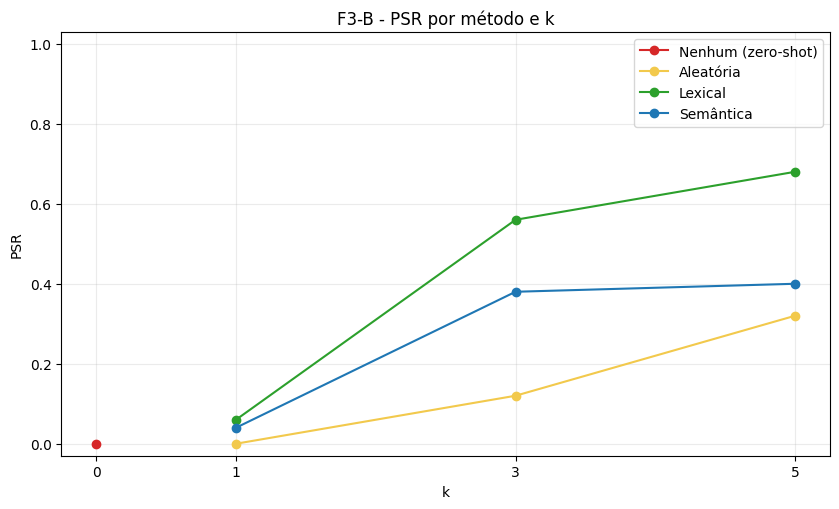

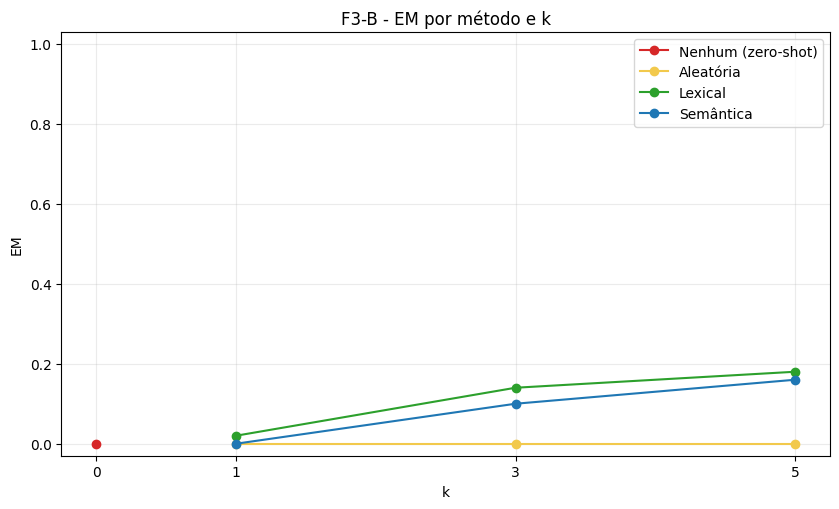

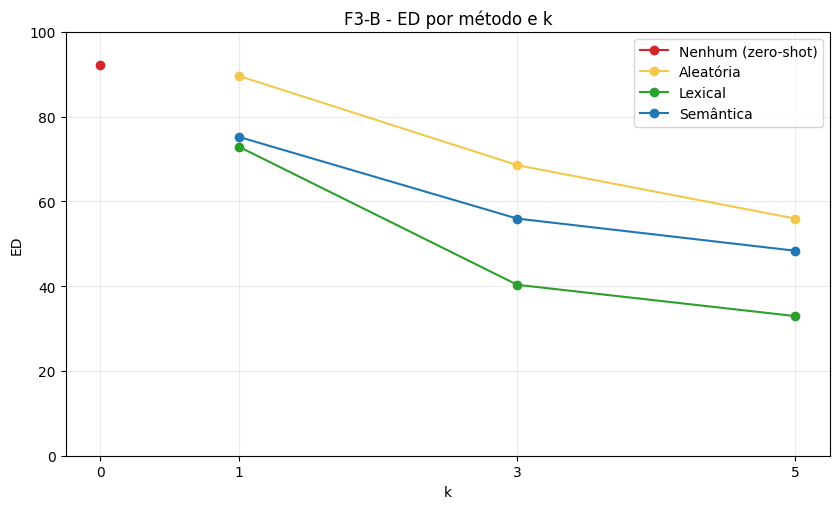

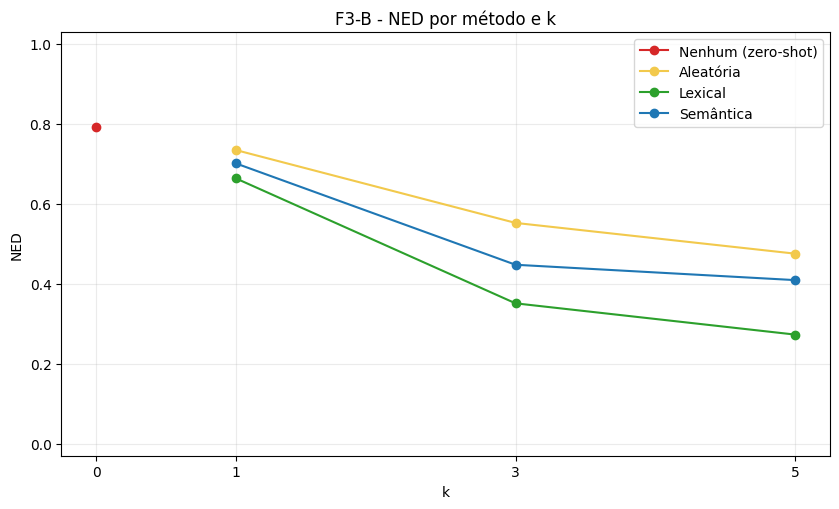

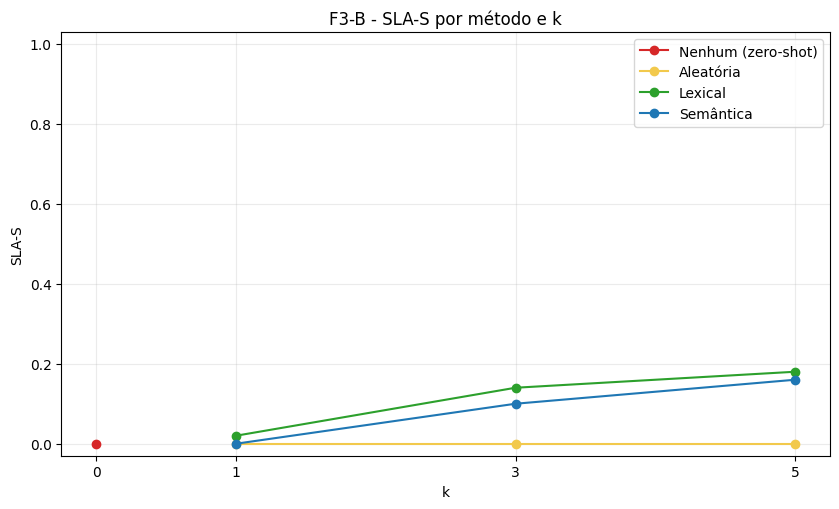

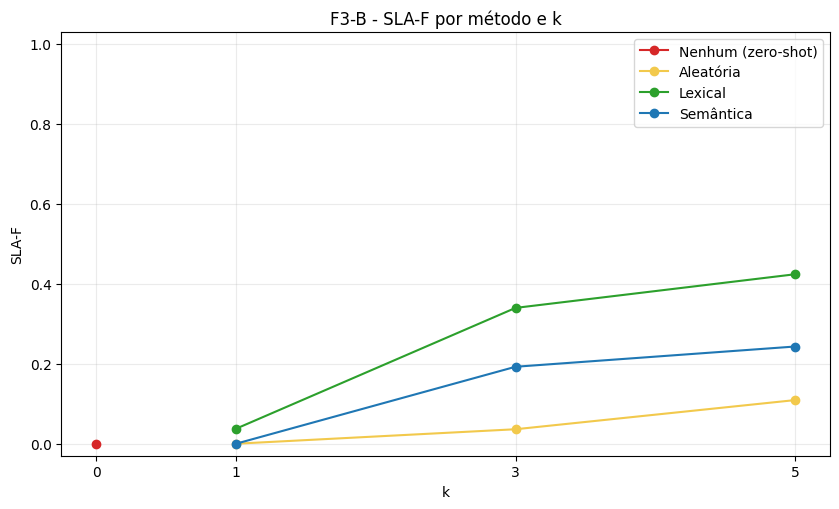

método de seleção,rótulo do método,k,registros,autocorreção aplicada,PSR,EM,ED,NED,SLA-S,SLA-F,validade sintática,tokens do prompt,tokens gerados,tempo em segundos
zero_shot,Nenhum (zero-shot),0,50,50,0.00,0.00,92.28,0.792636,0.00,0.000000,0,648.720000,19.520000,1.115774
random_seed42,Aleatória,1,50,50,0.00,0.00,89.56,0.734287,0.00,0.000000,0,704.280000,21.660000,1.218889
lexical_tfidf,Lexical,1,50,47,0.06,0.02,72.84,0.663407,0.02,0.037500,3,700.085106,17.595745,1.011694
semantic_embeddings,Semântica,1,50,48,0.04,0.00,75.18,0.700898,0.00,0.000000,2,702.020833,17.187500,0.982766
random_seed42,Aleatória,3,50,46,0.12,0.00,68.54,0.552179,0.00,0.036212,6,832.152174,23.195652,1.327199
lexical_tfidf,Lexical,3,50,22,0.56,0.14,40.32,0.351075,0.14,0.339657,28,829.909091,20.136364,1.169838
semantic_embeddings,Semântica,3,50,34,0.38,0.10,55.94,0.447547,0.10,0.192475,19,827.705882,22.882353,1.317029
random_seed42,Aleatória,5,50,36,0.32,0.00,55.94,0.475304,0.00,0.109116,16,949.916667,21.750000,1.276806
lexical_tfidf,Lexical,5,50,19,0.68,0.18,32.94,0.272920,0.18,0.423783,34,954.947368,26.368421,1.522315
semantic_embeddings,Semântica,5,50,31,0.40,0.16,48.36,0.409153,0.16,0.243086,20,952.225806,20.677419,1.223971


fold,método de seleção,rótulo do método,k,registros,autocorreção aplicada,PSR,EM,ED,NED,SLA-S,SLA-F
1,zero_shot,Nenhum (zero-shot),0,10,10,0.0,0.0,99.1,0.794120,0.0,0.000000
1,random_seed42,Aleatória,1,10,10,0.0,0.0,86.9,0.726448,0.0,0.000000
1,lexical_tfidf,Lexical,1,10,10,0.0,0.0,89.2,0.687519,0.0,0.000000
1,semantic_embeddings,Semântica,1,10,10,0.0,0.0,79.7,0.725927,0.0,0.000000
1,random_seed42,Aleatória,3,10,9,0.1,0.0,77.6,0.548860,0.0,0.075000
1,lexical_tfidf,Lexical,3,10,5,0.5,0.1,39.0,0.340401,0.1,0.345707
1,semantic_embeddings,Semântica,3,10,7,0.4,0.1,51.4,0.443492,0.1,0.231818
1,random_seed42,Aleatória,5,10,6,0.4,0.0,53.4,0.431241,0.0,0.170833
1,lexical_tfidf,Lexical,5,10,5,0.6,0.2,41.5,0.345666,0.2,0.409596
1,semantic_embeddings,Semântica,5,10,8,0.3,0.1,61.9,0.464791,0.1,0.226263


método de seleção,rótulo do método,k,psr f3a,psr f3b,delta psr,em f3a,em f3b,delta em,ed f3a,ed f3b,reduction ed,ned f3a,ned f3b,reduction ned,sla s f3a,sla s f3b,delta sla s,sla f f3a,sla f f3b,delta sla f
zero_shot,Nenhum (zero-shot),0,0.00,0.00,0.00,0.00,0.00,0.00,90.18,92.28,-2.10,0.787434,0.792636,-0.005202,0.00,0.00,0.00,0.000000,0.000000,0.000000e+00
random_seed42,Aleatória,1,0.00,0.00,0.00,0.00,0.00,0.00,88.24,89.56,-1.32,0.732616,0.734287,-0.001671,0.00,0.00,0.00,0.000000,0.000000,0.000000e+00
lexical_tfidf,Lexical,1,0.06,0.06,0.00,0.02,0.02,0.00,70.54,72.84,-2.30,0.660313,0.663407,-0.003094,0.02,0.02,0.00,0.037500,0.037500,0.000000e+00
semantic_embeddings,Semântica,1,0.04,0.04,0.00,0.00,0.00,0.00,74.86,75.18,-0.32,0.689701,0.700898,-0.011197,0.00,0.00,0.00,0.000000,0.000000,0.000000e+00
random_seed42,Aleatória,3,0.08,0.12,0.04,0.00,0.00,0.00,66.64,68.54,-1.90,0.557389,0.552179,0.005209,0.00,0.00,0.00,0.021667,0.036212,1.454545e-02
lexical_tfidf,Lexical,3,0.56,0.56,0.00,0.14,0.14,0.00,37.58,40.32,-2.74,0.324390,0.351075,-0.026685,0.14,0.14,0.00,0.339657,0.339657,5.551115e-17
semantic_embeddings,Semântica,3,0.32,0.38,0.06,0.08,0.10,0.02,56.78,55.94,0.84,0.472790,0.447547,0.025243,0.08,0.10,0.02,0.144697,0.192475,4.777778e-02
random_seed42,Aleatória,5,0.28,0.32,0.04,0.00,0.00,0.00,57.38,55.94,1.44,0.488992,0.475304,0.013688,0.00,0.00,0.00,0.099116,0.109116,1.000000e-02
lexical_tfidf,Lexical,5,0.62,0.68,0.06,0.18,0.18,0.00,34.72,32.94,1.78,0.290621,0.272920,0.017701,0.18,0.18,0.00,0.379338,0.423783,4.444444e-02
semantic_embeddings,Semântica,5,0.38,0.40,0.02,0.16,0.16,0.00,49.44,48.36,1.08,0.415708,0.409153,0.006555,0.16,0.16,0.00,0.234197,0.243086,8.888889e-03


método de seleção,rótulo do método,k,registros,autocorreção aplicada,sintaxe recuperada,em recovered,ed reduction,ned reduction
zero_shot,Nenhum (zero-shot),0,50,50,0,0,-2.10,-0.005202
random_seed42,Aleatória,1,50,50,0,0,-1.32,-0.001671
lexical_tfidf,Lexical,1,50,47,0,0,-2.30,-0.003094
semantic_embeddings,Semântica,1,50,48,0,0,-0.32,-0.011197
random_seed42,Aleatória,3,50,46,2,0,-1.90,0.005209
lexical_tfidf,Lexical,3,50,22,0,0,-2.74,-0.026685
semantic_embeddings,Semântica,3,50,34,3,1,0.84,0.025243
random_seed42,Aleatória,5,50,36,2,0,1.44,0.013688
lexical_tfidf,Lexical,5,50,19,3,0,1.78,0.017701
semantic_embeddings,Semântica,5,50,31,1,0,1.08,0.006555


fold,ID,método de seleção,rótulo do método,k,nl,reference nile,nile initial,response autocorrection raw,nile evaluated,autocorreção aplicada,validade sintática,validator feedback
1,campi_001,zero_shot,Nenhum (zero-shot),0,"If a student is in obvious violations of copyright law by using a room's wired connection (ie ResNet) to distribute copyrighted materials, the room's connection will be disabled, and the issue could be sent to Housing Student Judicial Affairs",define intent uniIntent: for group('students') add middlebox('copyright monitoring'),"disable room connection if a student violates copyright law by using room's wired connection (ResNet) to distribute copyrighted materials, report issue to Housing Student Judicial Affairs","if a student violates copyright law by using a room's wired connection (ResNet) to distribute copyrighted materials, the room's connection will be disabled, and the issue should be reported to Housing Student Judicial Affairs","if a student violates copyright law by using a room's wired connection (ResNet) to distribute copyrighted materials, the room's connection will be disabled, and the issue should be reported to Housing Student Judicial Affairs",sim,não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'if') at line 1, column 1.\nContexto: if a student violates copyright law by using \n^"
1,campi_002,zero_shot,Nenhum (zero-shot),0,"Currently, the University of Illinois does not have any rate limits",define intent uniIntent: for endpoint('university') unset bandwidth(),"currently, the university of illinois has no rate limits","currently, the university of illinois has no rate limits","currently, the university of illinois has no rate limits",sim,não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'currently') at line 1, column 1.\nContexto: currently, the university of illinois has no \n^"
1,campi_011,zero_shot,Nenhum (zero-shot),0,"MSN audio and video communications are not allowed by the University firewall, but the MSN chat, application sharing and file transferring are not blocked","define intent uniIntent: for endpoint('university') add middlebox('firewall') block service('MSN video'), service('MSN audio') allow service('MSN chat'), service('MSN application sharing'), service('file transfer')","MSN audio and video communications are not permitted by the University's firewall, but the MSN chat, application sharing, and file transfer functionalities are not restricted.","MSN audio and video communications are not allowed by the University firewall, but the MSN chat, application sharing, and file transferring functionalities are not blocked.","MSN audio and video communications are not allowed by the University firewall, but the MSN chat, application sharing, and file transferring functionalities are not blocked.",sim,não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'MSN') at line 1, column 1.\nContexto: MSN audio and video communications are not al\n^"
1,campi_012,zero_shot,Nenhum (zero-shot),0,Net2Phone is allowed by the University firewall,define intent uniIntent: for endpoint('university') add middlebox('firewall') allow service('Net2Phone'),`net2phone is permitted by the university firewall`,```nile\nnet2phone is allowed by the university firewall\n```,net2phone is allowed by the university firewall,sim,não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'net2phone') at line 1, column 1.\nContexto: net2phone is allowed by the university firewa\n^"
1,campi_020,zero_shot,Nenhum (zero-shot),0,FTP and SFTP servers are allowed by the University firewall,"define intent uniIntent: for endpoint('university') add middlebox('firewall') allow protocol('ftp'), protocol('sftp')",allowed_by_the_university_firewall,allowed_by_the_university_firewall,allowed_by_the_university_firewall,sim,não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'allowed_by_the_university_firewall') at line 1, column 1.\

ID,conditions,autocorrections,PSR,EM,ED,NED,SLA-S,SLA-F,valid outputs
campi_004,10,10,0.0,0.0,81.0,0.750000,0.0,0.000000,0
campi_005,10,10,0.0,0.0,85.3,0.661240,0.0,0.000000,0
campi_018,10,10,0.0,0.0,79.1,0.775490,0.0,0.000000,0
campi_023,10,10,0.0,0.0,48.1,0.581630,0.0,0.000000,0
campi_027,10,10,0.0,0.0,72.3,0.602853,0.0,0.000000,0
campi_038,10,10,0.0,0.0,52.0,0.500000,0.0,0.000000,0
campi_041,10,10,0.0,0.0,68.7,0.723158,0.0,0.000000,0
campi_030,10,9,0.1,0.0,66.5,0.560992,0.0,0.000000,1
campi_032,10,9,0.1,0.0,123.3,0.648062,0.0,0.000000,1
campi_036,10,9,0.1,0.0,69.7,0.518403,0.0,0.000000,1


Bloco 9 concluído.
Condições consolidadas: 10
Saídas finais inválidas: 372
Gráficos produzidos: 6
Status: OK


In [9]:
# ----------------------------------------------------------
# 9.1 Resumos por condição e por fold
# ----------------------------------------------------------

summary_df = (
    results_df
    .groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        autocorrection_applied=("autocorrection_applied", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        syntax_valid=("syntax_valid", "sum"),
        prompt_tokens=("prompt_autocorrection_tokens", "mean"),
        generated_tokens=("generated_autocorrection_tokens", "mean"),
        elapsed_seconds=("elapsed_autocorrection_seconds", "mean"),
    )
    .reset_index()
)
summary_df["_ordem_metodo"] = summary_df["selection_method"].map(ORDEM_METODOS_MAPA)
summary_df = (
    summary_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
summary_df.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

summary_fold_df = (
    results_df
    .groupby(["fold", "selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        autocorrection_applied=("autocorrection_applied", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)
summary_fold_df["_ordem_metodo"] = (
    summary_fold_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
summary_fold_df = (
    summary_fold_df
    .sort_values(["fold", "k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
summary_fold_df.to_csv(SUMMARY_FOLD_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.2 Saídas inválidas e análise por exemplo
# ----------------------------------------------------------

invalid_df = results_df.loc[
    ~results_df["syntax_valid"].astype(bool),
    [
        "fold",
        "id",
        "selection_method",
        "selection_label",
        "k",
        "nl",
        "reference_nile",
        "nile_initial",
        "response_autocorrection_raw",
        "nile_evaluated",
        "autocorrection_applied",
        "syntax_valid",
        "validator_feedback",
    ],
].copy()
invalid_df["_ordem_metodo"] = invalid_df["selection_method"].map(ORDEM_METODOS_MAPA)
invalid_df = (
    invalid_df
    .sort_values(["fold", "k", "_ordem_metodo", "id"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
invalid_df.to_csv(INVALID_PATH, index=False, encoding="utf-8")

analysis_example_df = (
    results_df
    .groupby("id", dropna=False)
    .agg(
        conditions=("id", "count"),
        autocorrections=("autocorrection_applied", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        valid_outputs=("syntax_valid", "sum"),
    )
    .reset_index()
    .sort_values(["psr", "sla_f", "em", "id"], ascending=[True, True, True, True])
)
analysis_example_df.to_csv(
    ANALYSIS_EXAMPLE_PATH,
    index=False,
    encoding="utf-8",
)


# ----------------------------------------------------------
# 9.3 Comparação F3-A × F3-B
# ----------------------------------------------------------

f3a_summary_df = pd.read_csv(F3A_OPERACIONAL_DIR / "f3a_summary.csv")
comparison_df = f3a_summary_df.merge(
    summary_df,
    on=["selection_method", "selection_label", "k"],
    suffixes=("_f3a", "_f3b"),
    validate="one_to_one",
)

for metric in ["psr", "em", "sla_s", "sla_f"]:
    comparison_df[f"delta_{metric}"] = (
        comparison_df[f"{metric}_f3b"]
        - comparison_df[f"{metric}_f3a"]
    )
comparison_df["reduction_ed"] = comparison_df["ed_f3a"] - comparison_df["ed_f3b"]
comparison_df["reduction_ned"] = comparison_df["ned_f3a"] - comparison_df["ned_f3b"]
comparison_df["_ordem_metodo"] = comparison_df["selection_method"].map(ORDEM_METODOS_MAPA)
comparison_df = (
    comparison_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
comparison_df.to_csv(COMPARISON_PATH, index=False, encoding="utf-8")

source_metrics = f3a_results_df[[
    "fold",
    "id",
    "selection_method",
    "selection_label",
    "k",
    "psr",
    "em",
    "ed",
    "ned",
    "sla_s",
    "sla_f",
    "syntax_valid",
]].copy()
source_metrics = source_metrics.rename(columns={
    "psr": "psr_before",
    "em": "em_before",
    "ed": "ed_before",
    "ned": "ned_before",
    "sla_s": "sla_s_before",
    "sla_f": "sla_f_before",
    "syntax_valid": "syntax_valid_before",
})

final_metrics = results_df[[
    "fold",
    "id",
    "selection_method",
    "selection_label",
    "k",
    "autocorrection_applied",
    "psr",
    "em",
    "ed",
    "ned",
    "sla_s",
    "sla_f",
    "syntax_valid",
]].copy()
final_metrics = final_metrics.rename(columns={
    "psr": "psr_after",
    "em": "em_after",
    "ed": "ed_after",
    "ned": "ned_after",
    "sla_s": "sla_s_after",
    "sla_f": "sla_f_after",
    "syntax_valid": "syntax_valid_after",
})

record_gain_df = source_metrics.merge(
    final_metrics,
    on=["fold", "id", "selection_method", "selection_label", "k"],
    validate="one_to_one",
)
record_gain_df["syntax_recovered"] = (
    (~record_gain_df["syntax_valid_before"].astype(bool))
    & record_gain_df["syntax_valid_after"].astype(bool)
)
record_gain_df["em_recovered"] = (
    record_gain_df["em_after"] > record_gain_df["em_before"]
)
record_gain_df["ed_reduction"] = record_gain_df["ed_before"] - record_gain_df["ed_after"]
record_gain_df["ned_reduction"] = record_gain_df["ned_before"] - record_gain_df["ned_after"]

gains_df = (
    record_gain_df
    .groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        autocorrection_applied=("autocorrection_applied", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
        em_recovered=("em_recovered", "sum"),
        ed_reduction=("ed_reduction", "mean"),
        ned_reduction=("ned_reduction", "mean"),
    )
    .reset_index()
)
gains_df["_ordem_metodo"] = gains_df["selection_method"].map(ORDEM_METODOS_MAPA)
gains_df = (
    gains_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
gains_df.to_csv(GAINS_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.4 Gráficos independentes das seis métricas
# ----------------------------------------------------------

import matplotlib.pyplot as plt

LIMITES_EIXO_Y = {
    "psr": (-0.03, 1.03),
    "em": (-0.03, 1.03),
    "ed": (0.0, 100.0),
    "ned": (-0.03, 1.03),
    "sla_s": (-0.03, 1.03),
    "sla_f": (-0.03, 1.03),
}

TICKS_EIXO_Y = {
    "psr": np.arange(0.0, 1.01, 0.2),
    "em": np.arange(0.0, 1.01, 0.2),
    "ed": np.arange(0.0, 100.1, 20.0),
    "ned": np.arange(0.0, 1.01, 0.2),
    "sla_s": np.arange(0.0, 1.01, 0.2),
    "sla_f": np.arange(0.0, 1.01, 0.2),
}

for metrica, (limite_inferior, limite_superior) in (
    LIMITES_EIXO_Y.items()
):
    valores = pd.to_numeric(
        summary_df[metrica],
        errors="coerce",
    ).dropna()

    if valores.empty:
        raise ValueError(
            f"A métrica {metrica} não possui valores para o gráfico."
        )

    if (
        float(valores.min()) < limite_inferior - 1e-12
        or float(valores.max()) > limite_superior + 1e-12
    ):
        raise ValueError(
            f"A métrica {metrica} ultrapassa a escala gráfica fixada."
        )

GRAFICOS_PATHS = {}
for metric in METRICAS:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for method in ORDEM_METODOS_EXIBICAO:
        subset = summary_df.loc[
            summary_df["selection_method"] == method
        ].sort_values("k")
        if subset.empty:
            continue
        ax.plot(
            subset["k"],
            subset[metric],
            marker="o",
            label=ROTULOS_METODOS[method],
            color=CORES_METODOS[method],
        )

    ax.set_title(f"F3-B - {ROTULOS_METRICAS[metric]} por método e k")
    ax.set_xlabel("k")
    ax.set_ylabel(ROTULOS_METRICAS[metric])
    ax.set_xticks([0, 1, 3, 5])
    limite_inferior, limite_superior = LIMITES_EIXO_Y[metric]
    ax.set_ylim(
        limite_inferior,
        limite_superior,
    )
    ax.set_yticks(
        TICKS_EIXO_Y[metric],
    )
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()

    graph_path = GRAFICOS_DIR / f"f3b_{metric}.png"
    fig.savefig(graph_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    GRAFICOS_PATHS[metric] = graph_path


# ----------------------------------------------------------
# 9.5 Exibição das análises
# ----------------------------------------------------------

exibir_tabela(summary_df, "Desempenho consolidado da F3-B por método e k")
exibir_tabela(summary_fold_df, "Desempenho por fold, método e k", altura_px=460)
exibir_tabela(
    comparison_df[[
        "selection_method",
        "selection_label",
        "k",
        "psr_f3a",
        "psr_f3b",
        "delta_psr",
        "em_f3a",
        "em_f3b",
        "delta_em",
        "ed_f3a",
        "ed_f3b",
        "reduction_ed",
        "ned_f3a",
        "ned_f3b",
        "reduction_ned",
        "sla_s_f3a",
        "sla_s_f3b",
        "delta_sla_s",
        "sla_f_f3a",
        "sla_f_f3b",
        "delta_sla_f",
    ]],
    "Comparação F3-A × F3-B",
    altura_px=460,
)
exibir_tabela(gains_df, "Ganhos atribuídos à primeira autocorreção")

if not invalid_df.empty:
    exibir_tabela(
        invalid_df.head(30),
        "Amostra das saídas finais inválidas",
        altura_px=460,
    )
exibir_tabela(
    analysis_example_df.head(25),
    "Exemplos com menor desempenho agregado",
    altura_px=460,
)

print("Bloco 9 concluído.")
print(f"Condições consolidadas: {len(summary_df)}")
print(f"Saídas finais inválidas: {len(invalid_df)}")
print(f"Gráficos produzidos: {len(GRAFICOS_PATHS)}")
print("Status: OK")

## Bloco 10 - Manifesto e empacotamento final

### Objetivo

Este bloco encerra a F3-B, executa as barreiras finais de integridade e cria o pacote operacional utilizado pela consolidação experimental e pela etapa complementar de autocorreção final.

### Barreiras da execução oficial

O pacote só é criado quando:

- o modo de teste rápido está desativado;
- existem 500 decisões e 500 resultados;
- prompts e gerações correspondem exatamente aos elegíveis;
- nenhuma saída sintaticamente válida da F3-A recebeu autocorreção;
- nenhuma saída sintaticamente inválida foi omitida;
- saídas preservadas mantêm texto e métricas da F3-A;
- tokens auditados correspondem aos tokens da inferência;
- todos os prompts respeitam o limite de contexto;
- as dez condições possuem 50 registros;
- todos os registros atendem ao schema.

### Manifesto

O manifesto registra:

- hashes do F3-modelo e da F3-A;
- política de elegibilidade;
- modelo e ambiente;
- quantidade de chamadas efetivamente realizadas;
- PSR antes e depois e valores das demais métricas;
- resultados por condição;
- inventário e SHA-256 de todos os arquivos.

### Pacote final

O arquivo produzido é:

```text
f3b_autocorrecao_traducao_direta.zip
```

O ZIP é criado sem pasta externa repetida e é reaberto para conferir nomes, corrupção e hashes.

### Resultado esperado

A F3-B é considerada concluída somente quando o pacote contém todos os artefatos previstos e todas as barreiras são atendidas.

In [10]:
# ----------------------------------------------------------
# 10.1 Barreiras finais da execução oficial
# ----------------------------------------------------------

if MODO_TESTE_RAPIDO:
    raise RuntimeError(
        "O modo de teste rápido está ativo. Desative-o e execute os Blocos 6 a 10 "
        "para produzir o pacote oficial da F3-B."
    )

if len(plan_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O pacote oficial exige 500 decisões.")
if len(prompt_records) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("A quantidade de prompts diverge dos elegíveis.")
if len(generation_records) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("A quantidade de gerações diverge dos elegíveis.")
if len(result_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O pacote oficial exige 500 resultados.")

prompt_token_map = {
    str(record["execution_id"]): int(record["prompt_tokens"])
    for record in prompt_records
}
generation_token_map = {
    str(record["execution_id"]): int(record["prompt_tokens"])
    for record in generation_records
}
if prompt_token_map != generation_token_map:
    raise ValueError("A auditoria de tokens diverge da inferência.")
if max(prompt_token_map.values()) + MAX_NEW_TOKENS_NILE > CONTEXT_LIMIT:
    raise ValueError("Há prompt fora do limite de contexto.")

if results_df["status"].ne("completed").any():
    raise ValueError("Há resultados não concluídos.")
if results_df.shape[0] != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("Quantidade final de resultados divergente.")
if int(results_df["autocorrection_applied"].sum()) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("Quantidade de autocorreções aplicadas divergente.")
if len(summary_df) != TOTAL_CONDICOES_ESPERADO or not summary_df["records"].eq(50).all():
    raise ValueError("O resumo não contém dez condições de 50 registros.")
if len(analysis_example_df) != TOTAL_EXEMPLOS_ESPERADO:
    raise ValueError("A análise por exemplo deve conter 50 IDs.")

plan_by_key = {
    (
        int(record["fold"]),
        str(record["id"]),
        str(record["selection_method"]),
        int(record["k"]),
    ): record
    for record in plan_records
}
result_by_key = {
    (
        int(record["fold"]),
        str(record["id"]),
        str(record["selection_method"]),
        int(record["k"]),
    ): record
    for record in result_records
}
if set(plan_by_key) != set(result_by_key):
    raise ValueError("As chaves dos resultados divergem do plano.")

for key, plan_record in plan_by_key.items():
    result = result_by_key[key]
    eligible = bool(plan_record["eligible_for_autocorrection"])
    if bool(result["autocorrection_applied"]) != eligible:
        raise ValueError(f"Decisão de autocorreção divergente para {key}.")
    if not eligible:
        source = f3a_by_key[key]
        if str(result["nile_evaluated"]) != str(source["nile_evaluated"]):
            raise ValueError(f"Saída preservada foi alterada para {key}.")
        for metric in METRICAS:
            if not np.isclose(
                float(result[metric]),
                float(source[metric]),
                rtol=0,
                atol=1e-12,
            ):
                raise ValueError(
                    f"Métrica preservada foi alterada para {key}: {metric}."
                )


# ----------------------------------------------------------
# 10.2 Configuração consolidada
# ----------------------------------------------------------

config_final = {
    **configuracao_inicial,
    "inputs": {
        "f3_modelo_source": str(FONTE_F3_MODELO["path"]),
        "f3_modelo_source_type": FONTE_F3_MODELO["type"],
        "f3_modelo_manifest_sha256": f3_modelo_manifest_sha256,
        "f3a_source": str(FONTE_F3A["path"]),
        "f3a_source_type": FONTE_F3A["type"],
        "f3a_manifest_sha256": f3a_manifest_sha256,
    },
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "source_used": str(MODEL_SOURCE),
        "source_type": MODEL_SOURCE_TYPE,
        "device": model_device,
        "dtype": model_dtype,
        "context_limit": CONTEXT_LIMIT,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "observed": {
        "conditions": int(len(summary_df)),
        "source_results": int(len(f3a_result_records)),
        "eligible_for_autocorrection": int(TOTAL_ELEGIVEIS_ESPERADO),
        "prompts": int(len(prompt_records)),
        "generations": int(len(generation_records)),
        "final_results": int(len(result_records)),
        "syntax_valid_before": int(f3a_results_df["syntax_valid"].sum()),
        "syntax_valid_after": int(results_df["syntax_valid"].sum()),
        "syntax_recovered": int(result_audit_df["syntax_recovered"].sum()),
        "invalid_outputs": int(len(invalid_df)),
        "prompt_tokens_min": int(token_audit_df["prompt_tokens"].min()),
        "prompt_tokens_max": int(token_audit_df["prompt_tokens"].max()),
        "max_reserved_tokens": int(token_audit_df["reserved_tokens"].max()),
    },
}
write_json(config_final, CONFIG_PATH)


# ----------------------------------------------------------
# 10.3 Inventário e manifesto
# ----------------------------------------------------------

clean_runtime_caches(F3B_DIR)

package_files = [
    CONFIG_PATH,
    PLANO_PATH,
    PROMPTS_PATH,
    TOKEN_AUDIT_PATH,
    GENERATIONS_PATH,
    RESULTS_JSONL_PATH,
    RESULTS_CSV_PATH,
    SUMMARY_PATH,
    SUMMARY_FOLD_PATH,
    INVALID_PATH,
    ANALYSIS_EXAMPLE_PATH,
    EXECUTION_AUDIT_PATH,
    COMPARISON_PATH,
    GAINS_PATH,
    *[GRAFICOS_PATHS[metric] for metric in METRICAS],
]

missing_files = [str(path) for path in package_files if not Path(path).is_file()]
if missing_files:
    raise FileNotFoundError("Arquivos finais ausentes: " + ", ".join(missing_files))

file_inventory = []
for path in package_files:
    path = Path(path)
    if path.is_relative_to(PACOTE_DIR):
        relative = path.relative_to(PACOTE_DIR).as_posix()
    elif path.is_relative_to(GRAFICOS_DIR):
        relative = "graficos/" + path.name
    else:
        relative = path.name
    file_inventory.append({
        "file": relative,
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    })

manifest = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variant": VARIANTE,
    "description": NOME_ESTRATEGIA,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": DATASET,
    "inputs": {
        "f3_modelo_manifest_sha256": f3_modelo_manifest_sha256,
        "f3a_manifest_sha256": f3a_manifest_sha256,
        "f0_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f0_manifest_sha256"),
        "f1_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f1_manifest_sha256"),
        "f2_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f2_manifest_sha256"),
    },
    "experimental_design": {
        "folds": TOTAL_FOLDS_ESPERADO,
        "examples": TOTAL_EXEMPLOS_ESPERADO,
        "conditions": TOTAL_CONDICOES_ESPERADO,
        "records": TOTAL_REGISTROS_ESPERADO,
        "k_values": VALORES_K,
        "few_shot_k_values": K_FEWSHOT,
        "selection_methods": [METODO_ZERO_SHOT, *METODOS_FEWSHOT],
        "formal_equivalent_demonstrations_excluded": True,
    },
    "model": config_final["student_model"],
    "metrics": {
        "names": ["PSR", "EM", "ED", "NED", "SLA-S", "SLA-F"],
        "internal_fields": METRICAS,
        "embedding_metric_used": False,
    },
    "method": {
        "teacher_model_used": False,
        "fine_tuning_used": False,
        "intermediate_representation_used_in_prompt": False,
        "rationales_used_in_prompt": False,
        "autocorrection_used": True,
        "autocorrection_attempt": 1,
        "autocorrection_only_for_syntax_invalid": True,
        "same_few_shot_demonstrations_as_f3a": True,
        "test_reference_exposed": False,
        "checkpoint_resume_enabled": True,
    },
    "results": {
        "eligible_for_autocorrection": int(TOTAL_ELEGIVEIS_ESPERADO),
        "autocorrections_applied": int(results_df["autocorrection_applied"].sum()),
        "syntax_valid_before": int(f3a_results_df["syntax_valid"].sum()),
        "syntax_valid_after": int(results_df["syntax_valid"].sum()),
        "syntax_recovered": int(result_audit_df["syntax_recovered"].sum()),
        "invalid_outputs": int(len(invalid_df)),
        "summary": summary_df.to_dict(orient="records"),
    },
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "packages": {
            "torch": package_version("torch"),
            "transformers": package_version("transformers"),
            "accelerate": package_version("accelerate"),
            "pandas": package_version("pandas"),
            "numpy": package_version("numpy"),
            "lark": package_version("lark"),
            "jsonschema": package_version("jsonschema"),
            "matplotlib": package_version("matplotlib"),
            "tqdm": package_version("tqdm"),
        },
    },
    "files": file_inventory,
}
write_json(manifest, MANIFEST_PATH)


# ----------------------------------------------------------
# 10.4 Criação e verificação do ZIP
# ----------------------------------------------------------

if ZIP_FINAL_PATH.exists():
    ZIP_FINAL_PATH.unlink()

with zipfile.ZipFile(ZIP_FINAL_PATH, "w", compression=zipfile.ZIP_DEFLATED) as package:
    for path, item in zip(package_files, file_inventory):
        package.write(path, arcname=item["file"])
    package.write(MANIFEST_PATH, arcname="manifest.json")

with zipfile.ZipFile(ZIP_FINAL_PATH, "r") as package:
    names = package.namelist()
    corrupted = package.testzip()
    for item in file_inventory:
        actual = hashlib.sha256(package.read(item["file"])).hexdigest()
        if actual != item["sha256"]:
            raise ValueError(f"Hash divergente no ZIP: {item['file']}")

if corrupted is not None:
    raise ValueError(f"Arquivo corrompido no ZIP: {corrupted}")
if len(names) != len(set(names)):
    raise ValueError("O ZIP contém nomes duplicados.")
if any(name.startswith("f3b_autocorrecao_traducao_direta/") for name in names):
    raise ValueError("O ZIP contém uma pasta externa repetida.")

final_summary_df = pd.DataFrame([
    {"item": "condições", "value": len(summary_df)},
    {"item": "resultados finais", "value": len(results_df)},
    {"item": "autocorreções aplicadas", "value": int(results_df["autocorrection_applied"].sum())},
    {"item": "sintaticamente válidas antes", "value": int(f3a_results_df["syntax_valid"].sum())},
    {"item": "sintaticamente válidas depois", "value": int(results_df["syntax_valid"].sum())},
    {"item": "arquivos inventariados", "value": len(file_inventory)},
    {"item": "arquivos no ZIP", "value": len(names)},
    {"item": "ZIP final", "value": str(ZIP_FINAL_PATH)},
])

exibir_tabela(final_summary_df, "Resumo final da F3-B")

print("Bloco 10 concluído.")
print("F3-B concluída e empacotada.")
print(f"Manifesto: {MANIFEST_PATH}")
print(f"ZIP final: {ZIP_FINAL_PATH}")
print("Pasta externa repetida: não")
print("Integridade do ZIP: confirmada")
print("Status: OK")

item,valor
condições,10
resultados finais,500
autocorreções aplicadas,383
sintaticamente válidas antes,117
sintaticamente válidas depois,128
arquivos inventariados,20
arquivos no ZIP,21
ZIP final,/kaggle/working/f3b_autocorrecao_traducao_direta.zip


Bloco 10 concluído.
F3-B concluída e empacotada.
Manifesto: /kaggle/working/f3b_autocorrecao_traducao_direta/pacote/manifest.json
ZIP final: /kaggle/working/f3b_autocorrecao_traducao_direta.zip
Pasta externa repetida: não
Integridade do ZIP: confirmada
Status: OK
